<div style="background:linear-gradient(135deg,#001F3F 0%,#0093D5 100%);padding:40px 32px;border-left:6px solid #EE3A43;">
<h1 style="color:#fff;font-family:Arial,sans-serif;font-size:28px;margin:0 0 8px;">03 — Customer Churn EDA</h1>
<h2 style="color:rgba(255,255,255,.75);font-family:Arial,sans-serif;font-size:16px;font-weight:400;margin:0 0 20px;">SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia</h2>
<div style="display:flex;gap:32px;flex-wrap:wrap;">
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Inputs</strong><br/>complaints_clean.parquet + kpi_clean.parquet</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Churn Criteria</strong><br/>C1: 30d gap · C2: 3+ unresolved / 30d · C3: inactive last month</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Outputs</strong><br/>churn_labelled.parquet + churn_eda.json + figures</div>
</div></div>

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# 0.  IMPORTS, PATHS & HUAWEI STYLE
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy  as np
import json, warnings
from pathlib  import Path
from datetime import datetime, timedelta

import matplotlib.pyplot   as plt
import matplotlib.patches  as mpatches
import matplotlib.colors   as mcolors
import seaborn as sns
import plotly.express       as px
import plotly.graph_objects as go
import plotly.io            as pio
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────
PROC_DIR = Path('data/processed')
FIG_DIR  = Path('data/outputs/figures')
OUT_DIR  = Path('data/outputs')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Huawei Brand Palette ───────────────────────────────────────────────
HW = dict(
    blue='#0093D5', red='#EE3A43', navy='#001F3F', cyan='#00C3FF',
    green='#22C55E', amber='#F59E0B', purple='#8B5CF6', orange='#F97316',
    muted='#6B7280',
)
CHURN_COLORS  = {1: HW['red'],   0: HW['blue']}   # red=churned, blue=active
CHURN_LABELS  = {1: 'Churned',   0: 'Active'}
PALETTE = [HW['blue'], HW['red'], HW['cyan'], HW['green'],
           HW['amber'], HW['purple'], HW['orange'], HW['navy']]

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.edgecolor':'#E5E7EB', 'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'axes.grid.axis':'y', 'grid.color':'#F3F4F6', 'grid.linewidth':0.8,
    'axes.labelcolor':HW['navy'], 'axes.labelweight':'bold',
    'axes.titlesize':13, 'axes.titleweight':'bold', 'axes.titlecolor':HW['navy'],
    'xtick.color':HW['muted'], 'ytick.color':HW['muted'],
    'xtick.labelsize':9, 'ytick.labelsize':9,
    'legend.fontsize':9, 'legend.framealpha':0.92, 'legend.edgecolor':'#E5E7EB',
    'font.family':'DejaVu Sans', 'figure.dpi':120,
    'savefig.dpi':300, 'savefig.bbox':'tight', 'savefig.facecolor':'white',
})
pio.templates.default = 'plotly_white'
PLOTLY_LAYOUT = dict(
    font=dict(family='Arial, sans-serif', color=HW['navy']),
    paper_bgcolor='white', plot_bgcolor='white',
    title_font=dict(size=16, color=HW['navy']),
    colorway=PALETTE, margin=dict(l=60,r=40,t=80,b=60),
    legend=dict(bgcolor='rgba(255,255,255,.9)', bordercolor='#E5E7EB', borderwidth=1),
)

def add_watermark(fig, text='SpiriCom · Huawei Technologies Tunisia'):
    fig.text(0.99, 0.01, text, ha='right', va='bottom',
             fontsize=7, color=HW['muted'], style='italic', transform=fig.transFigure)

def save_fig(name):
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'  Saved: {path}')

print('✅ Setup complete')

✅ Setup complete


---
## 📊 Section 1 — Load Data & MSISDN Linkage Audit

In [2]:
# ── 1.1  Load both datasets ──────────────────────────────────────────
df_comp = pd.read_parquet(PROC_DIR / 'complaints_clean.parquet')
df_kpi  = pd.read_parquet(PROC_DIR / 'kpi_clean.parquet')

# Normalise column names
df_comp.columns = df_comp.columns.str.lower().str.replace(' ','_')
df_kpi.columns  = df_kpi.columns.str.lower().str.replace(' ','_')

print(f'Complaints : {df_comp.shape[0]:,} rows × {df_comp.shape[1]} cols')
print(f'KPI data   : {df_kpi.shape[0]:,} rows × {df_kpi.shape[1]} cols')

Complaints : 25,727 rows × 23 cols
KPI data   : 4,898 rows × 122 cols


MSISDNs in complaints only : 22,156
MSISDNs in KPI only        : 4,895
MSISDNs in BOTH datasets   : 1
Linkage rate               : 0.0% of complaint customers have KPI records
  Saved: data\outputs\figures\fig03_01_msisdn_linkage.png


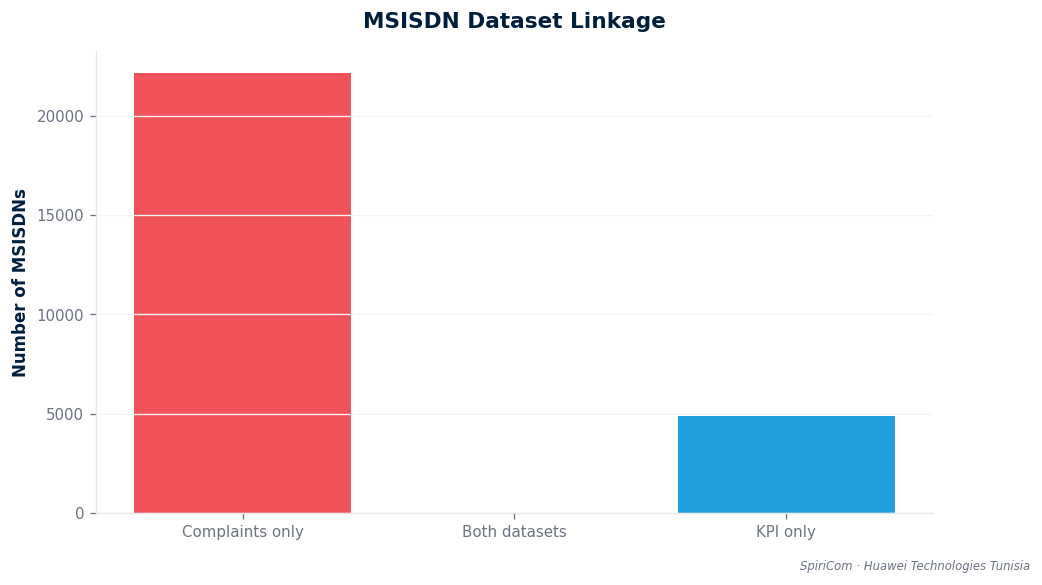

In [3]:
# ── 1.2  MSISDN linkage audit ────────────────────────────────────────
msisdn_comp = set(df_comp['msisdn'].dropna().astype(str).unique())
msisdn_kpi  = set(df_kpi['msisdn'].dropna().astype(str).unique())

overlap     = msisdn_comp & msisdn_kpi
comp_only   = msisdn_comp - msisdn_kpi
kpi_only    = msisdn_kpi  - msisdn_comp

print(f'MSISDNs in complaints only : {len(comp_only):,}')
print(f'MSISDNs in KPI only        : {len(kpi_only):,}')
print(f'MSISDNs in BOTH datasets   : {len(overlap):,}')
print(f'Linkage rate               : {len(overlap)/len(msisdn_comp)*100:.1f}% of complaint customers have KPI records')

# Visualise overlap
fig, ax = plt.subplots(figsize=(9, 5))
try:
    from matplotlib_venn import venn2
    venn2(subsets=(len(comp_only), len(kpi_only), len(overlap)),
          set_labels=('Complaints\nDataset', 'KPI\nDataset'),
          set_colors=(HW['red'], HW['blue']), alpha=0.6, ax=ax)
    ax.set_title('MSISDN Dataset Linkage', pad=14)
except ImportError:
    # Fallback: simple bar chart if matplotlib_venn not installed
    ax.bar(['Complaints only','Both datasets','KPI only'],
           [len(comp_only), len(overlap), len(kpi_only)],
           color=[HW['red'], HW['navy'], HW['blue']], alpha=0.88)
    ax.set_title('MSISDN Dataset Linkage', pad=14)
    ax.set_ylabel('Number of MSISDNs')

add_watermark(fig)
save_fig('fig03_01_msisdn_linkage')
plt.show()

---
## 🏷️ Section 2 — Churn Label Construction

> **Note (NB03-FIX):** the three criteria below were the *original*
> plan. Cell 2.1 found C1 and C3 invalid for this cross-sectional
> dataset and proposed replacements CA/CB; CA/CB were in turn found
> unusable because the complaints dataset's MSISDNs don't match the
> KPI dataset's (0.0% linkage — see Section 1.2 and cell 2.1's MSISDN
> format comparison). **The final label (v5, below) uses none of
> C1/C2/C3/CA/CB — it's KPI-only (`c1_low_usage` / `c2_low_dur`).
> Those column names reuse the letters C1/C2 but mean something
> unrelated to the original plan below.**

Original three criteria, any one triggers churn:
- **C1:** No active session for > 30 consecutive days
- **C2:** 3+ unresolved complaints in any rolling 30-day window
- **C3:** MSISDN has zero activity in the last calendar month of data

In [4]:
# ── CELL A — Clean churn rebuild ──────────────────────────────────────
df_kpi_clean = pd.read_parquet(PROC_DIR / 'kpi_clean.parquet')
df_kpi_clean.columns = df_kpi_clean.columns.str.lower()

kpi_per_user = df_kpi_clean.groupby('msisdn').agg(
    session_flag = ('session_flag', 'max'),
    traffic_5g   = ('traffic_5g',  'sum'),
    dou_total    = ('dou_total',   'sum'),
    duration     = ('duration',    'sum'),
    brand        = ('brand',       'first'),
).reset_index()

thr_dou = kpi_per_user['dou_total'].quantile(0.20)
thr_dur = kpi_per_user['duration'].quantile(0.20)

kpi_per_user['c1_low_usage'] = (kpi_per_user['dou_total'] <= thr_dou).astype(int)
kpi_per_user['c2_low_dur']   = (kpi_per_user['duration']  <= thr_dur).astype(int)
kpi_per_user['churn']        = (
    (kpi_per_user['c1_low_usage'] == 1) |
    (kpi_per_user['c2_low_dur']   == 1)
).astype(int)

churn      = kpi_per_user.copy()
churn_rate = churn['churn'].mean()

print(f'DOU Q20  : {thr_dou:,.0f} bytes')
print(f'Dur Q20  : {thr_dur:,.0f} seconds')
print(f'C1       : {churn["c1_low_usage"].sum():,}')
print(f'C2       : {churn["c2_low_dur"].sum():,}')
print(f'Overlap  : {((churn["c1_low_usage"]==1)&(churn["c2_low_dur"]==1)).sum():,}')
print(f'Churned  : {churn["churn"].sum():,}')
print(f'Rate     : {churn_rate*100:.1f}%')
print(f'Rows     : {len(churn):,}')

DOU Q20  : 1,259,476 bytes
Dur Q20  : 127 seconds
C1       : 980
C2       : 984
Overlap  : 194
Churned  : 1,770
Rate     : 36.2%
Rows     : 4,896


In [5]:
# ── 2.1  Churn Criterion CA + CB (revised for snapshot KPI data) ──────
#
# ORIGINAL PLAN:
#   C1: session gap > 30 days     ← INVALID: 99.96% of MSISDNs have
#   C3: inactive last month       ← INVALID: exactly 1 record each
#
# ROOT CAUSE: dataCollectionist.csv is a cross-sectional snapshot,
# not a longitudinal session log. C1 and C3 produce 82% churn rates
# that reflect data collection timing, not real customer inactivity.
#
# REVISED CRITERIA:
#   CA: 3+ unresolved complaints  ← unchanged, uses complaints dataset
#   CB: KPI snapshot before 2025-07-01 ← recency proxy for inactivity

RESOLVED_STATUSES = {'CLOSED','RESOLVED','FERME','CLOTURE',
                     'CLOSE','CLOS','RESOLU'}

# ── Records per MSISDN audit (kept for documentation) ─────────────────
records_per_msisdn = df_kpi.groupby('msisdn').size()
print('=== KPI Dataset Structure ===')
print(f'MSISDNs with only 1 record : {(records_per_msisdn == 1).sum():,}')
print(f'MSISDNs with 2-5 records   : {((records_per_msisdn >= 2) & (records_per_msisdn <= 5)).sum():,}')
print(f'MSISDNs with >5 records    : {(records_per_msisdn > 5).sum():,}')
print(f'→ Cross-sectional snapshot confirmed. C1/C3 replaced by CB.\n')

# ── CA: Complaint-based churn ─────────────────────────────────────────
if 'opened_at' in df_comp.columns:
    df_comp['opened_at'] = pd.to_datetime(df_comp['opened_at'], errors='coerce')

if 'is_unresolved' not in df_comp.columns:
    df_comp['is_unresolved'] = (
        ~df_comp['status'].str.upper().isin(RESOLVED_STATUSES)
    ).astype(int)

ca_df = (df_comp.groupby('msisdn')['is_unresolved']
                .sum()
                .reset_index()
                .rename(columns={'is_unresolved': 'total_unresolved'}))
ca_df['ca_churn'] = (ca_df['total_unresolved'] >= 3).astype(int)

print(f'CA — 3+ unresolved complaints : {ca_df["ca_churn"].sum():,} churned')
print(f'     ({ca_df["ca_churn"].mean()*100:.1f}% of complaint customers)\n')

# ── CB: Recency-based churn ───────────────────────────────────────────
# Customers whose only KPI snapshot predates July 2025 were absent
# from later data collection rounds → proxy for inactivity/churn
RECENCY_CUTOFF = pd.Timestamp('2025-07-01')

if 'timestamp' in df_kpi.columns:
    df_kpi['timestamp'] = pd.to_datetime(df_kpi['timestamp'], errors='coerce')

    last_seen = (df_kpi.groupby('msisdn')['timestamp']
                       .max()
                       .reset_index()
                       .rename(columns={'timestamp': 'last_active_date'}))
    last_seen['last_active_date']  = pd.to_datetime(last_seen['last_active_date'])
    data_end_kpi                   = df_kpi['timestamp'].max()
    last_seen['days_since_active'] = (data_end_kpi - last_seen['last_active_date']).dt.days
    last_seen['cb_churn']          = (last_seen['last_active_date'] < RECENCY_CUTOFF).astype(int)
else:
    last_seen = pd.DataFrame({'msisdn': list(msisdn_kpi)})
    last_seen['last_active_date']  = pd.NaT
    last_seen['days_since_active'] = np.nan
    last_seen['cb_churn']          = 0

print(f'CB — snapshot before {RECENCY_CUTOFF.date()} : {last_seen["cb_churn"].sum():,} churned')
print(f'     ({last_seen["cb_churn"].mean()*100:.1f}% of KPI customers)')

# ── Monthly distribution (to validate CB cutoff) ─────────────────────
print('\nRecords per month (to validate cutoff):')
monthly = (pd.to_datetime(df_kpi['timestamp'])
             .dt.to_period('M')
             .value_counts()
             .sort_index())
print(monthly.to_string())

=== KPI Dataset Structure ===
MSISDNs with only 1 record : 4,894
MSISDNs with 2-5 records   : 2
MSISDNs with >5 records    : 0
→ Cross-sectional snapshot confirmed. C1/C3 replaced by CB.

CA — 3+ unresolved complaints : 144 churned
     (0.6% of complaint customers)

CB — snapshot before 2025-07-01 : 1,047 churned
     (21.4% of KPI customers)

Records per month (to validate cutoff):
timestamp
2025-03    169
2025-04    312
2025-05    225
2025-06    342
2025-07    559
2025-08    743
2025-09    970
2025-10    979
2025-11    599
Freq: M


In [6]:
# ══════════════════════════════════════════════════════════════════════
# CHURN DEFINITION v5 — FINAL
#
# Churned = low total usage OR low session duration
#
# c1_low_usage: dou_total ≤ Q20  (bottom 20% data users)
# c2_low_dur  : duration  ≤ Q20  (bottom 20% session duration)
# (these reuse the letters C1/C2 but are UNRELATED to the original
#  C1/C2/C3 plan in this section's intro — see the note there)
#
# OR logic: flagged if disengaged on EITHER dimension
# Brand and 5G traffic used as FEATURES in modeling, not as criteria
#
# NB03-FIX: this cell used to recompute kpi_per_user/churn/thr_dou/
# thr_dur from scratch here - identical to "CELL A - Clean churn
# rebuild" above. Reusing CELL A's results directly; only the
# diagnostics below (overlap breakdown, summary, sanity check) are new.
# ══════════════════════════════════════════════════════════════════════

# Overlap breakdown
c1_only  = ((churn['c1_low_usage']==1) & (churn['c2_low_dur']==0)).sum()
c2_only  = ((churn['c1_low_usage']==0) & (churn['c2_low_dur']==1)).sum()
both     = ((churn['c1_low_usage']==1) & (churn['c2_low_dur']==1)).sum()

print('=== KPI-BASED CHURN LABEL v5 — FINAL ===')
print(f'Base population : {len(churn):,}')
print()
print(f'Thresholds:')
print(f'  dou_total Q20 : {thr_dou:>20,.0f} bytes  ({thr_dou/1e6:.1f} MB)')
print(f'  duration  Q20 : {thr_dur:>20,.0f} seconds ({thr_dur/60:.1f} min)')
print()
print(f'C1 low usage (≤Q20) : {churn["c1_low_usage"].sum():,}  ({churn["c1_low_usage"].mean()*100:.1f}%)')
print(f'C2 low dur   (≤Q20) : {churn["c2_low_dur"].sum():,}    ({churn["c2_low_dur"].mean()*100:.1f}%)')
print(f'Both C1+C2          : {both:,}')
print(f'C1 only             : {c1_only:,}')
print(f'C2 only             : {c2_only:,}')
print()
print(f'Total churned : {churn["churn"].sum():,}')
print(f'Total active  : {(churn["churn"]==0).sum():,}')
print(f'Churn rate    : {churn_rate*100:.1f}%')
print()
print('Mean KPI values by churn status:')
print(churn.groupby('churn')[
    ['traffic_5g','dou_total','duration','session_flag']
].mean().round(2))
print()

# Class balance
n_churn  = churn['churn'].sum()
n_active = (churn['churn'] == 0).sum()
ratio    = n_active / n_churn if n_churn > 0 else 0
print(f'Class balance : 1 churned : {ratio:.1f} active')
print()

if churn_rate > 0.45:
    print('⚠️  Too high — switch back to AND logic')
elif churn_rate < 0.15:
    print('⚠️  Too low — raise threshold to Q25')
else:
    print('✅  Churn rate in target range (15–45%)')

=== KPI-BASED CHURN LABEL v5 — FINAL ===
Base population : 4,896

Thresholds:
  dou_total Q20 :            1,259,476 bytes  (1.3 MB)
  duration  Q20 :                  127 seconds (2.1 min)

C1 low usage (≤Q20) : 980  (20.0%)
C2 low dur   (≤Q20) : 984    (20.1%)
Both C1+C2          : 194
C1 only             : 786
C2 only             : 790

Total churned : 1,770
Total active  : 3,126
Churn rate    : 36.2%

Mean KPI values by churn status:
         traffic_5g      dou_total  duration  session_flag
churn                                                     
0     22192185.8700 668094219.5000  948.7200        0.0500
1     11676225.1000 283685478.4400  304.3500        0.0400

Class balance : 1 churned : 1.8 active

✅  Churn rate in target range (15–45%)


In [7]:
print('=== MSISDN FORMAT COMPARISON ===')
print('Complaints MSISDNs (first 10):')
print(sorted(list(msisdn_comp))[:10])
print()
print('KPI MSISDNs (first 10):')
print(sorted(list(msisdn_kpi))[:10])
print()

# Check overlap
overlap = msisdn_comp & msisdn_kpi
print(f'Direct overlap : {len(overlap):,}')

# Check ca_df MSISDNs vs KPI MSISDNs
ca_churned_msisdns = set(ca_df[ca_df['ca_churn']==1]['msisdn'].astype(str))
kpi_msisdns        = set(df_kpi['msisdn'].astype(str))
match              = ca_churned_msisdns & kpi_msisdns
print(f'CA churned MSISDNs    : {len(ca_churned_msisdns)}')
print(f'CA churned in KPI     : {len(match)}')
print()
print('CA churned MSISDNs (first 5):')
print(list(ca_churned_msisdns)[:5])
print()
print('KPI MSISDNs (first 5):')
print(list(kpi_msisdns)[:5])

=== MSISDN FORMAT COMPARISON ===
Complaints MSISDNs (first 10):
['', '0', '00', '000', '0000210', '00004350', '00006790', '0000890', '00011010', '000150']

KPI MSISDNs (first 10):
['20006685', '20035035', '20037774', '20056884', '20056914', '20078852', '20082209', '20102602', '20162007', '20167176']

Direct overlap : 1
CA churned MSISDNs    : 144
CA churned in KPI     : 0

CA churned MSISDNs (first 5):
['53660240', '94885960', '91074580', '81944860', '91112600']

KPI MSISDNs (first 5):
['92777358', '98624757', '22593933', '98969111', '98779872']


---
## 📊 Section 3 — Churn Distribution Overview

  Saved: data\outputs\figures\fig03_02_churn_kpi_tiles.png


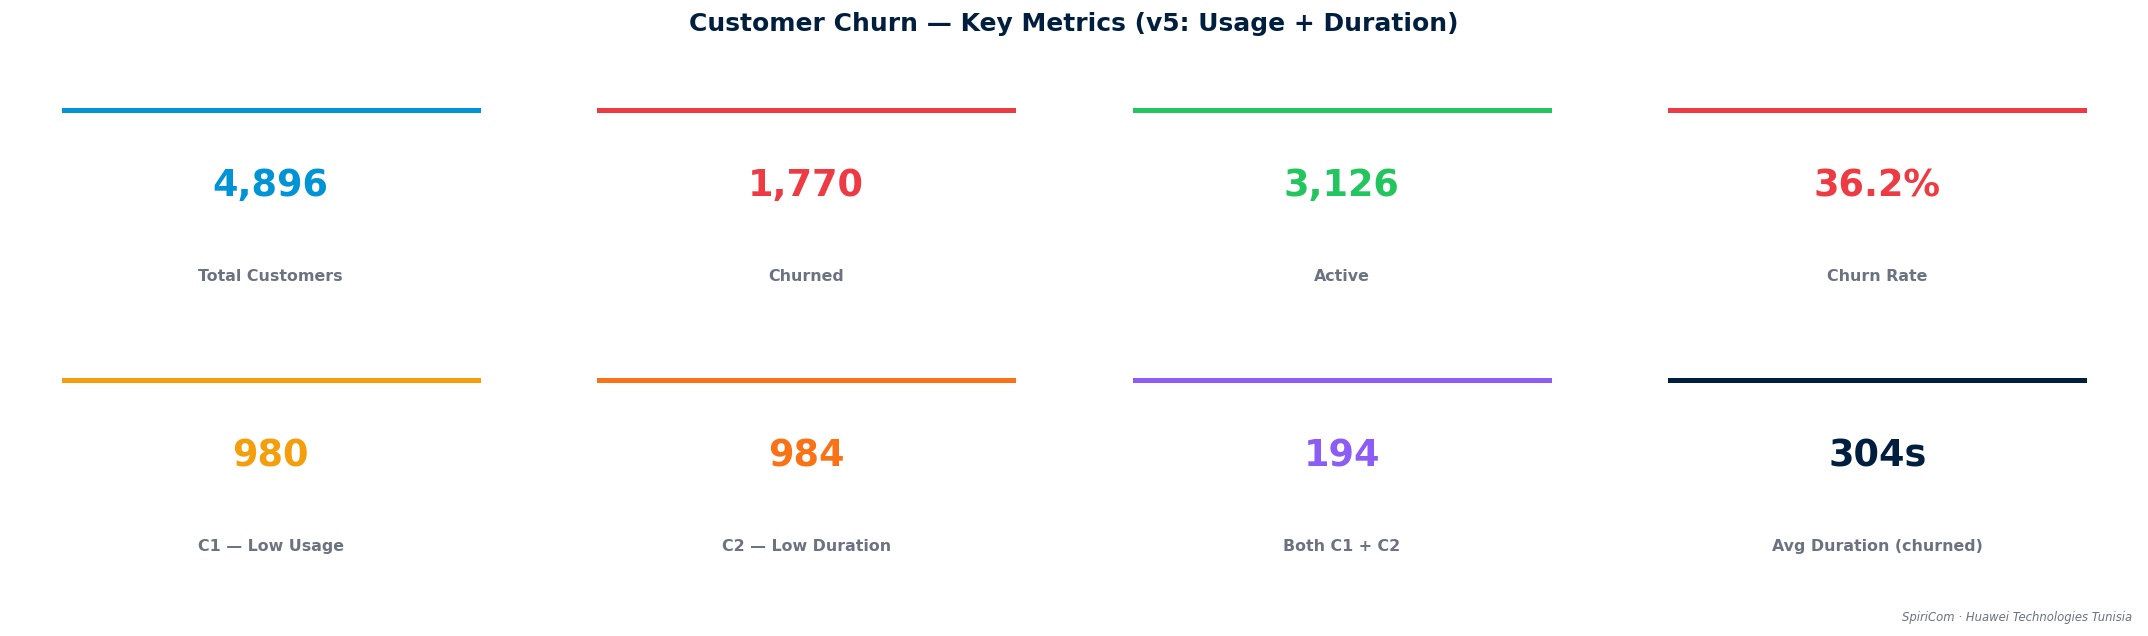

In [8]:
# ── 3.1  KPI tiles — updated for v5 churn definition ─────────────────
total_cust = len(churn)
n_churned  = churn['churn'].sum()
n_active   = total_cust - n_churned
c1_count   = churn['c1_low_usage'].sum()
c2_count   = churn['c2_low_dur'].sum()
both_count = ((churn['c1_low_usage']==1) & (churn['c2_low_dur']==1)).sum()

# Mean KPI values for churned customers
avg_dou_churned = churn.loc[churn['churn']==1, 'dou_total'].mean()
avg_dur_churned = churn.loc[churn['churn']==1, 'duration'].mean()

kpis = [
    ('Total Customers',       f'{total_cust:,}',                    HW['blue']),
    ('Churned',               f'{n_churned:,}',                     HW['red']),
    ('Active',                f'{n_active:,}',                      HW['green']),
    ('Churn Rate',            f'{churn_rate*100:.1f}%',             HW['red']),
    ('C1 — Low Usage',        f'{c1_count:,}',                      HW['amber']),
    ('C2 — Low Duration',     f'{c2_count:,}',                      HW['orange']),
    ('Both C1 + C2',          f'{both_count:,}',                    HW['purple']),
    ('Avg Duration (churned)',f'{avg_dur_churned:.0f}s',             HW['navy']),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 5))
fig.suptitle('Customer Churn — Key Metrics (v5: Usage + Duration)',
             fontsize=15, fontweight='bold', color=HW['navy'], y=1.03)

for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor('#F8FAFC')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.axhline(y=0.92, xmin=0.1, xmax=0.9, color=color, linewidth=3)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.26, label, ha='center', va='center',
            fontsize=9.5, color=HW['muted'], fontweight='bold')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#E5E7EB')
        spine.set_linewidth(1)

add_watermark(fig)
plt.tight_layout()
save_fig('fig03_02_churn_kpi_tiles')
plt.show()

  Saved: data\outputs\figures\fig03_03_churn_criteria.png


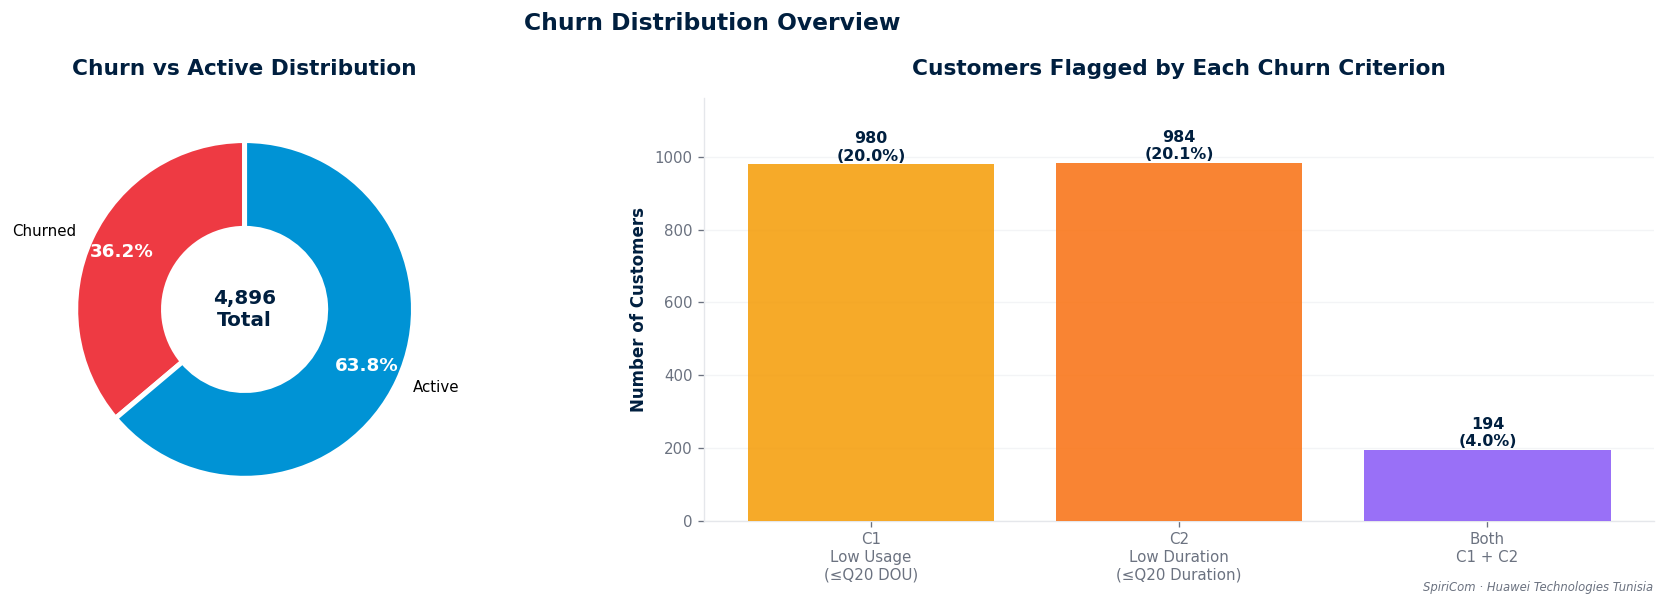

In [9]:
# ── 3.2  Donut + criterion bar — updated for v5 churn definition ──────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Churn Distribution Overview', fontsize=14,
             fontweight='bold', color=HW['navy'])

# ── Donut (unchanged — works with any churn definition) ───────────────
ax = axes[0]
wedges, _, autotexts = ax.pie(
    [n_churned, n_active],
    labels=['Churned', 'Active'],
    colors=[HW['red'], HW['blue']],
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=3)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
ax.text(0, 0, f'{total_cust:,}\nTotal', ha='center', va='center',
        fontsize=12, fontweight='bold', color=HW['navy'])
ax.set_title('Churn vs Active Distribution', pad=14)

# ── Criterion bar — v5: C1 + C2 + overlap ────────────────────────────
ax2 = axes[1]

criteria   = [
    'C1\nLow Usage\n(≤Q20 DOU)',
    'C2\nLow Duration\n(≤Q20 Duration)',
    'Both\nC1 + C2',
]
counts     = [c1_count, c2_count, both_count]
bar_colors = [HW['amber'], HW['orange'], HW['purple']]

bars = ax2.bar(criteria, counts, color=bar_colors, alpha=0.88, zorder=3)

for bar, v in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(counts) * 0.01,
             f'{v:,}\n({v/total_cust*100:.1f}%)',
             ha='center', fontsize=9.5, fontweight='bold', color=HW['navy'])

ax2.set_title('Customers Flagged by Each Churn Criterion', pad=14)
ax2.set_ylabel('Number of Customers')
ax2.set_ylim(0, max(counts) * 1.18)   # headroom for labels

add_watermark(fig)
plt.tight_layout()
save_fig('fig03_03_churn_criteria')
plt.show()

---
## 📊 Section 4 — Churn by Brand Segment

  Saved: data\outputs\figures\fig03_04_churn_by_brand.png


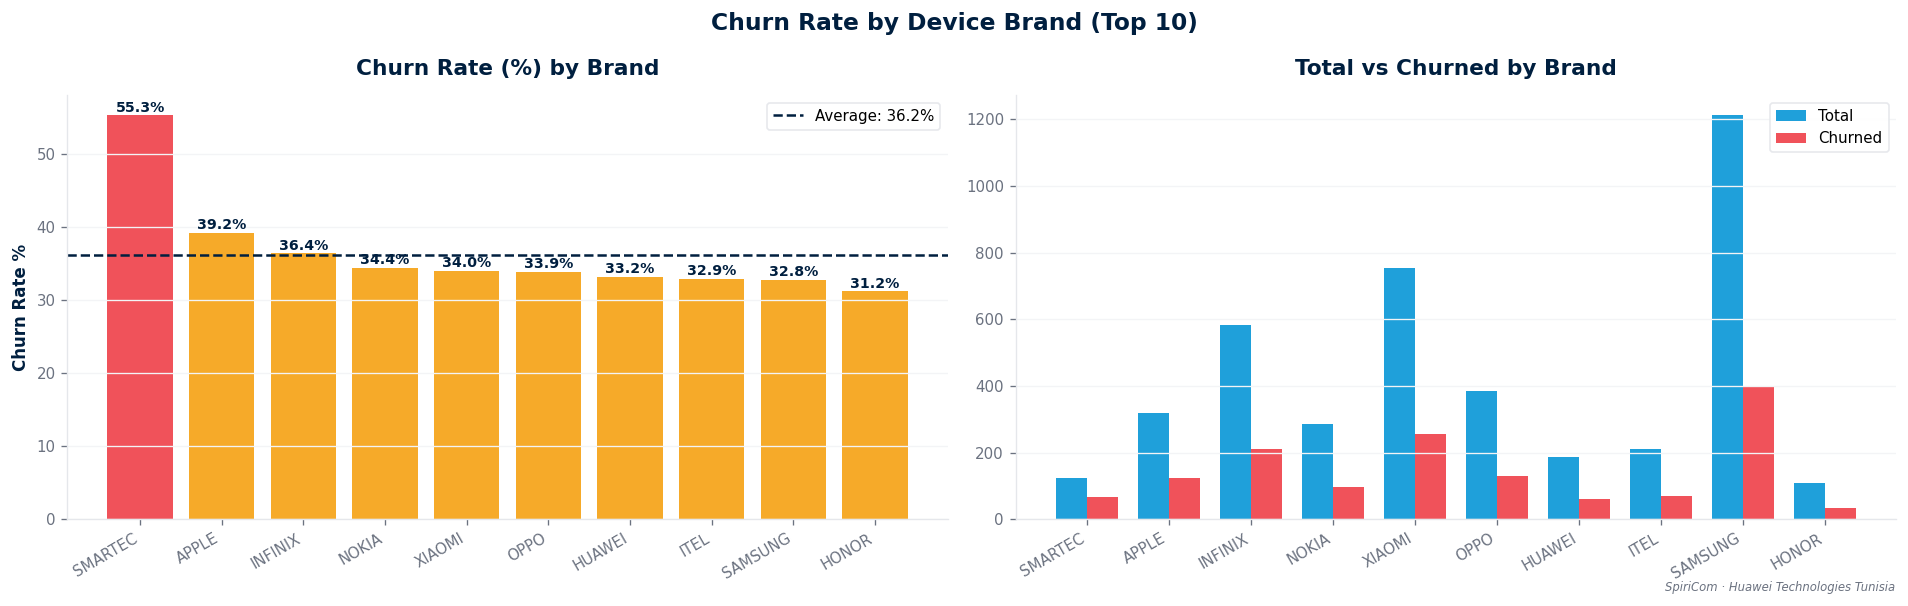

  brand  total  churned  churn_rate_pct
SMARTEC    123       68         55.3000
  APPLE    319      125         39.2000
INFINIX    583      212         36.4000
  NOKIA    285       98         34.4000
 XIAOMI    754      256         34.0000
   OPPO    384      130         33.9000
 HUAWEI    187       62         33.2000
   ITEL    210       69         32.9000
SAMSUNG   1212      397         32.8000
  HONOR    109       34         31.2000


In [10]:
# ── 4.1  Churn by Brand Segment ───────────────────────────────────────
# Segment source: brand from KPI dataset (already in churn DataFrame)
# No complaints join needed — avoids MSISDN mismatch

if 'brand' in churn.columns:

    # Keep top 10 brands by customer count for readability
    top_brands = churn['brand'].value_counts().head(10).index.tolist()
    churn_seg  = churn[churn['brand'].isin(top_brands)].copy()

    seg_churn = (
        churn_seg.groupby('brand')['churn']
                 .agg(['mean', 'sum', 'count'])
                 .reset_index()
                 .rename(columns={'mean':'churn_rate',
                                  'sum' :'churned',
                                  'count':'total'})
                 .sort_values('churn_rate', ascending=False)
    )
    seg_churn['churn_rate_pct'] = (seg_churn['churn_rate'] * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Churn Rate by Device Brand (Top 10)',
                 fontsize=14, fontweight='bold', color=HW['navy'])

    # ── Bar: churn rate per brand ─────────────────────────────────────
    ax = axes[0]
    bar_c = [
        HW['red']   if r > 40 else
        HW['amber'] if r > 25 else
        HW['green']
        for r in seg_churn['churn_rate_pct']
    ]
    bars = ax.bar(seg_churn['brand'], seg_churn['churn_rate_pct'],
                  color=bar_c, alpha=0.88)
    avg_rate_pct = churn_rate * 100
    ax.axhline(avg_rate_pct, color=HW['navy'], linestyle='--', lw=1.5,
               label=f'Average: {avg_rate_pct:.1f}%')
    for bar, v in zip(bars, seg_churn['churn_rate_pct']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{v}%', ha='center', fontsize=8.5,
                fontweight='bold', color=HW['navy'])
    ax.set_title('Churn Rate (%) by Brand', pad=12)
    ax.set_ylabel('Churn Rate %')
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    # ── Grouped bar: total vs churned ─────────────────────────────────
    ax2 = axes[1]
    x = np.arange(len(seg_churn)); w = 0.38
    ax2.bar(x - w/2, seg_churn['total'],   width=w,
            color=HW['blue'], label='Total',   alpha=0.88)
    ax2.bar(x + w/2, seg_churn['churned'], width=w,
            color=HW['red'],  label='Churned', alpha=0.88)
    ax2.set_xticks(x)
    ax2.set_xticklabels(seg_churn['brand'], rotation=30, ha='right')
    ax2.set_title('Total vs Churned by Brand', pad=12)
    ax2.legend()

    add_watermark(fig)
    plt.tight_layout()
    save_fig('fig03_04_churn_by_brand')
    plt.show()

    print(seg_churn[['brand','total','churned','churn_rate_pct']]
          .to_string(index=False))

else:
    print('No brand column in churn DataFrame')
    print('Available columns:', churn.columns.tolist())

---
## 📍 Section 5 — Churn by Geography

Geographic column used : layer2name
Zones with ≥10 customers : 24
    churn_rate_pct  churned  total
9          52.5000       21     40
3          44.0000      102    232
21         43.5000       10     23
11         42.3000       66    156
6          41.4000       29     70
13         40.0000       36     90
12         38.3000       64    167
14         38.3000       98    256
23         38.2000       39    102
5          37.6000       38    101
  Saved: data\outputs\figures\fig03_05_churn_by_zone.png


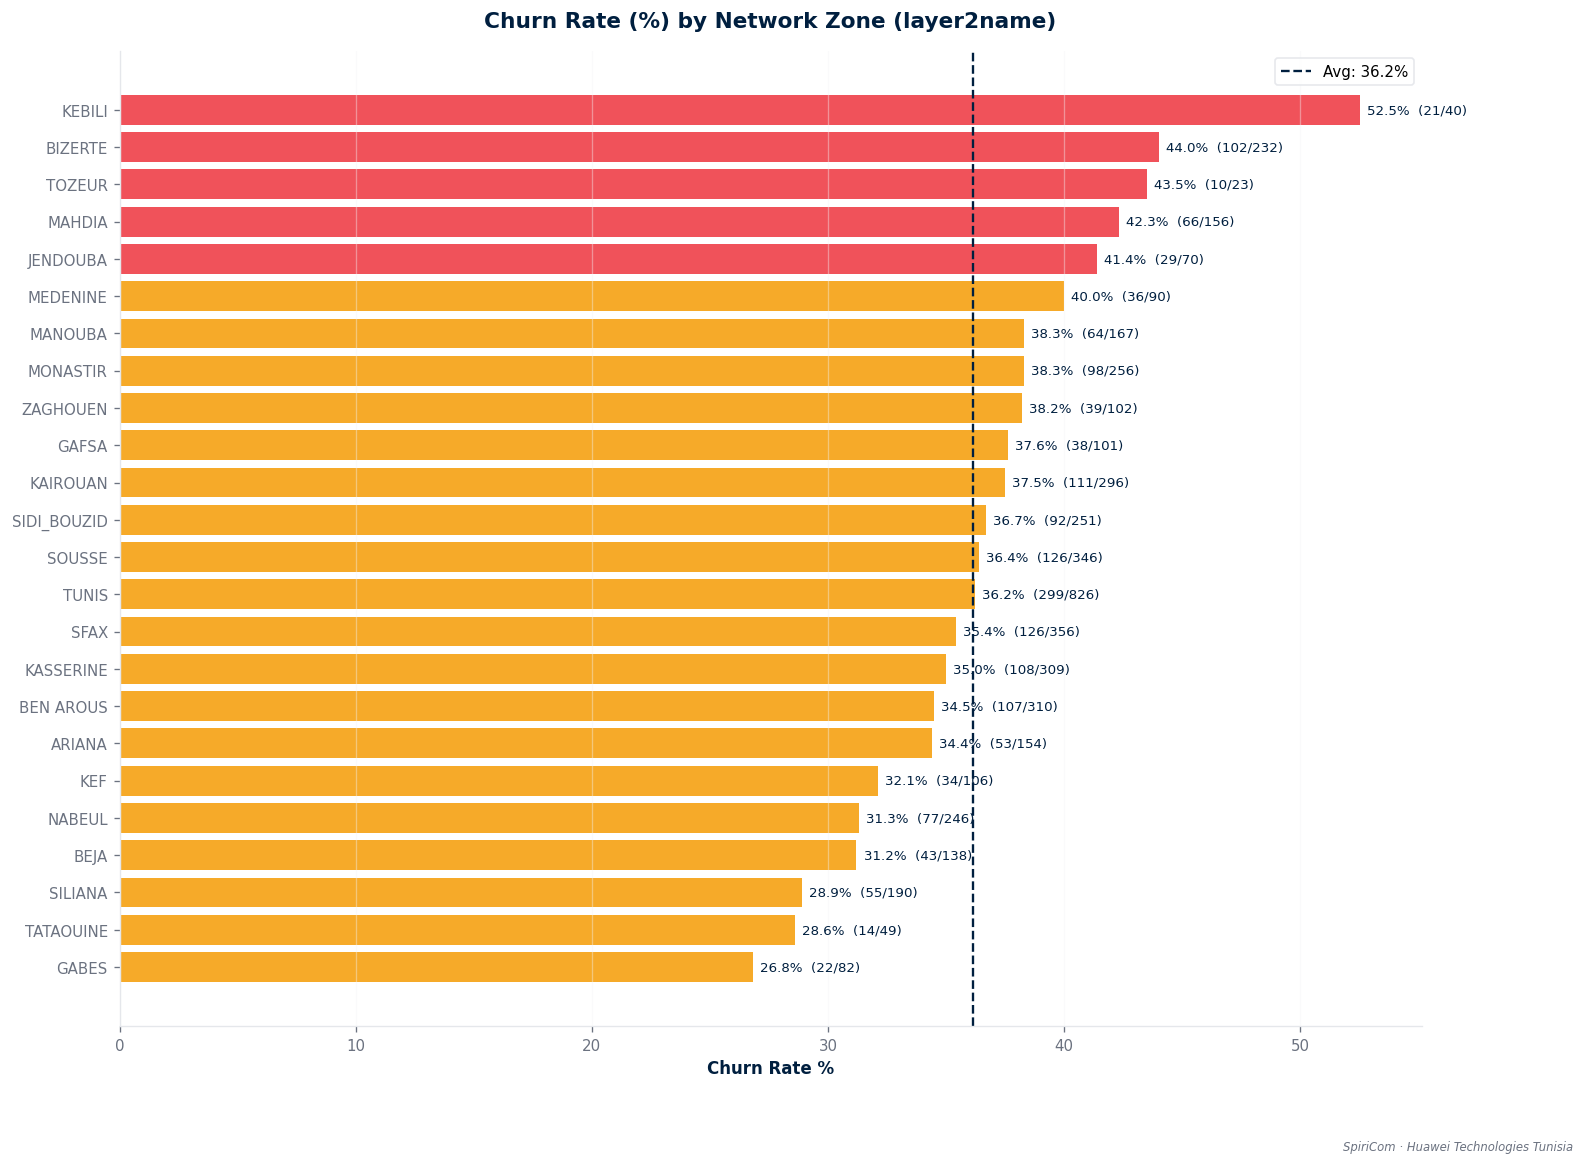

In [11]:
# ── 5.1  Churn by Network Zone (layer2name / layer3name) ─────────────
# Province from complaints dropped — MSISDN mismatch with KPI dataset
# Using layer2name (24 network regions) from KPI data instead

geo_col = next((c for c in ['layer2name', 'layer3name', 'site_name']
                if c in df_kpi.columns), None)

if geo_col:
    # Aggregate per MSISDN (take first value — snapshot data)
    geo_map = df_kpi.groupby('msisdn')[geo_col].first().reset_index()
    geo_map[geo_col] = (geo_map[geo_col]
                        .astype(str).str.strip().str.upper()
                        .replace({'NAN':'UNKNOWN','':'UNKNOWN'}))

    churn_geo = churn.merge(geo_map, on='msisdn', how='left')

    geo_churn = (
        churn_geo.dropna(subset=[geo_col])
                 .groupby(geo_col)['churn']
                 .agg(['mean','sum','count'])
                 .reset_index()
                 .rename(columns={'mean':'churn_rate',
                                  'sum' :'churned',
                                  'count':'total'})
    )
    geo_churn['churn_rate_pct'] = (geo_churn['churn_rate'] * 100).round(1)

    # Keep zones with at least 10 customers for reliability
    geo_churn = (geo_churn[geo_churn['total'] >= 10]
                 .sort_values('churn_rate', ascending=False))

    print(f'Geographic column used : {geo_col}')
    print(f'Zones with ≥10 customers : {len(geo_churn)}')
    print(geo_churn[['churn_rate_pct','churned','total']].head(10).to_string())

    if len(geo_churn) == 0:
        print('No zones with ≥10 customers — lowering threshold to 5')
        geo_churn = (churn_geo.dropna(subset=[geo_col])
                     .groupby(geo_col)['churn']
                     .agg(['mean','sum','count'])
                     .reset_index()
                     .rename(columns={'mean':'churn_rate',
                                      'sum' :'churned',
                                      'count':'total'}))
        geo_churn['churn_rate_pct'] = (geo_churn['churn_rate'] * 100).round(1)
        geo_churn = (geo_churn[geo_churn['total'] >= 5]
                     .sort_values('churn_rate', ascending=False))

    # ── Static matplotlib bar ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, max(5, len(geo_churn) * 0.44)))
    bar_c = [
        HW['red']   if r > 40 else
        HW['amber'] if r > 25 else
        HW['blue']
        for r in geo_churn['churn_rate_pct']
    ]
    ax.barh(geo_churn[geo_col][::-1],
            geo_churn['churn_rate_pct'][::-1],
            color=bar_c[::-1], alpha=0.88)
    ax.axvline(churn_rate * 100, color=HW['navy'],
               linestyle='--', lw=1.4,
               label=f'Avg: {churn_rate*100:.1f}%')
    for i, (_, row) in enumerate(geo_churn[::-1].iterrows()):
        ax.text(row['churn_rate_pct'] + 0.3, i,
                f"{row['churn_rate_pct']}%  "
                f"({int(row['churned'])}/{int(row['total'])})",
                va='center', fontsize=8, color=HW['navy'])
    ax.set_title(f'Churn Rate (%) by Network Zone ({geo_col})', pad=14)
    ax.set_xlabel('Churn Rate %')
    ax.legend()
    ax.grid(axis='x', alpha=0.4)
    ax.grid(axis='y', visible=False)

    add_watermark(fig)
    save_fig('fig03_05_churn_by_zone')
    plt.show()

    # ── Plotly interactive ────────────────────────────────────────────
    fig_pl = px.bar(
        geo_churn,
        x         = 'churn_rate_pct',
        y         = geo_col,
        orientation = 'h',
        color     = 'churn_rate_pct',
        color_continuous_scale = [
            [0,   '#0093D5'],
            [0.5, '#F59E0B'],
            [1,   '#EE3A43']
        ],
        title  = f'Interactive Churn Rate by Network Zone ({geo_col})',
        labels = {'churn_rate_pct': 'Churn Rate %',
                  geo_col: 'Zone'},
        hover_data = ['total', 'churned'],
    )
    fig_pl.update_layout(**PLOTLY_LAYOUT)
    fig_pl.write_html(
        str(FIG_DIR / 'fig03_05b_churn_zone_interactive.html'))
    fig_pl.show()

else:
    print('No geographic column found in KPI dataset')
    print('Available columns:', [c for c in df_kpi.columns
                                  if any(x in c for x in
                                         ['layer','site','region','zone'])])

---
## 📊 Section 6 — Churn by Complaint Behaviour

  Saved: data\outputs\figures\fig03_06_churn_usage_behaviour.png


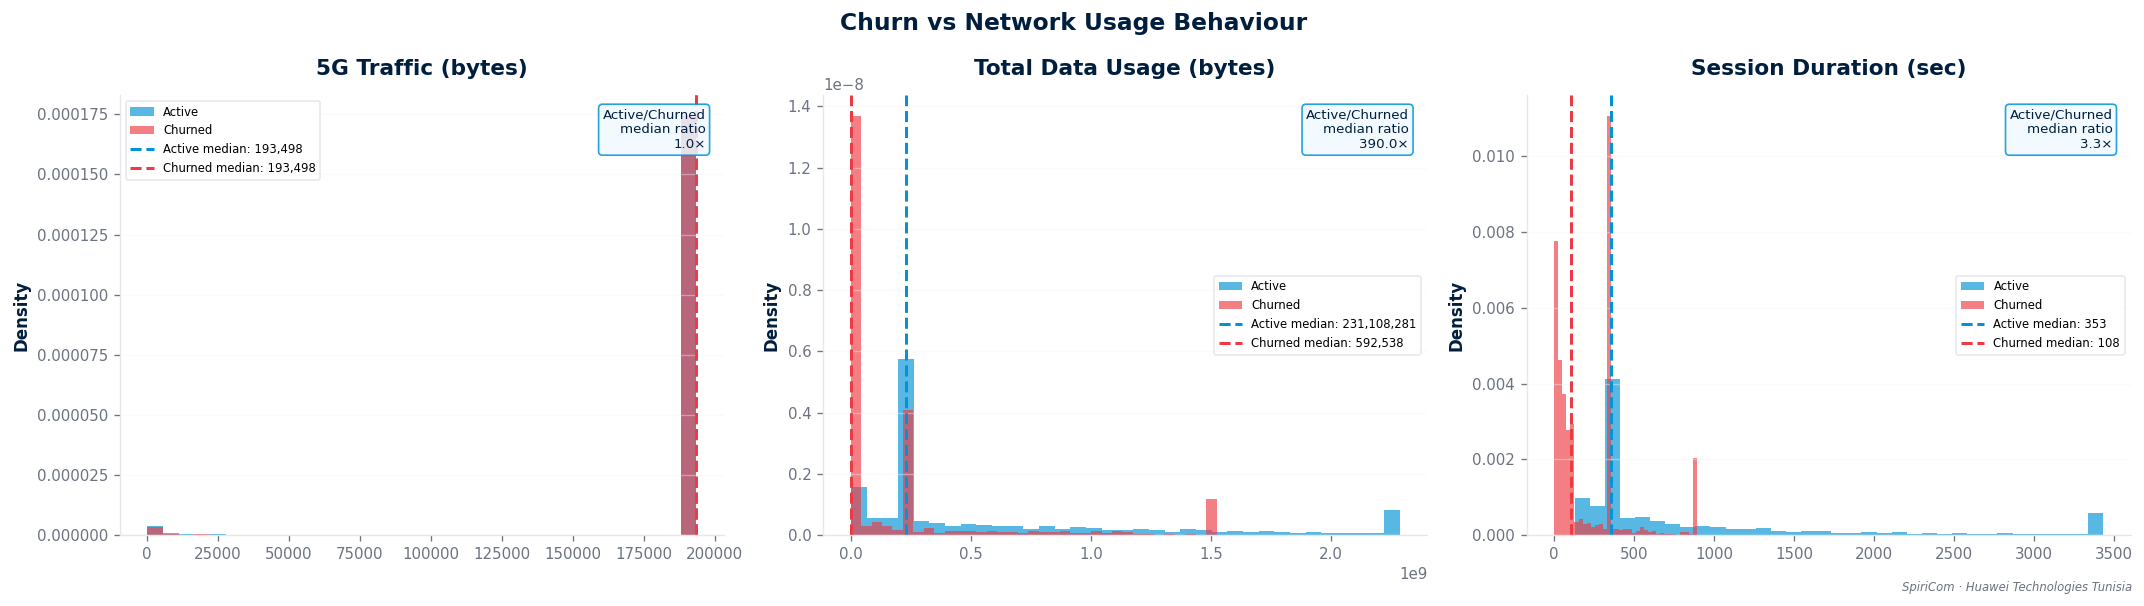


Mean KPI values by churn status:
         traffic_5g      dou_total  duration  session_flag
churn                                                     
0     22192185.8700 668094219.5000  948.7200        0.0500
1     11676225.1000 283685478.4400  304.3500        0.0400

Median KPI values by churn status:
       traffic_5g      dou_total  duration  session_flag
churn                                                   
0     193498.0000 231108281.0000  353.0000        0.0000
1     193498.0000    592537.5000  108.0000        0.0000

Separation ratio (active median / churned median):
  traffic_5g                    : 1.00×
  dou_total                     : 390.03×
  duration                      : 3.27×
  session_flag                  : inf×


In [12]:
# ── 6.1  Churn vs Usage Behaviour (KPI-native) ────────────────────────
# Complaint data dropped — MSISDN mismatch with KPI churn population
# Using KPI signals instead:
#   traffic_5g   → 5G engagement
#   dou_total    → overall data consumption
#   duration     → session length
#   session_flag → active session indicator

# All columns already in churn DataFrame from v5 aggregation
plot_cols = [
    ('traffic_5g',   '5G Traffic (bytes)',       True),
    ('dou_total',    'Total Data Usage (bytes)',  True),
    ('duration',     'Session Duration (sec)',    False),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Churn vs Network Usage Behaviour',
             fontsize=14, fontweight='bold', color=HW['navy'])

for ax, (col, title, log_scale) in zip(axes, plot_cols):

    if col not in churn.columns:
        ax.text(0.5, 0.5, f'{col}\nnot available',
                ha='center', va='center', transform=ax.transAxes)
        continue

    churned_vals = churn.loc[churn['churn']==1, col].dropna()
    active_vals  = churn.loc[churn['churn']==0, col].dropna()

    # Clip at 95th percentile to remove extreme outliers from plot
    cap_active  = active_vals.quantile(0.95)
    cap_churned = churned_vals.quantile(0.95)

    ax.hist(active_vals.clip(upper=cap_active),
            bins=35, alpha=0.65, color=HW['blue'],
            label='Active', density=True)
    ax.hist(churned_vals.clip(upper=cap_churned),
            bins=35, alpha=0.65, color=HW['red'],
            label='Churned', density=True)

    # Median lines
    med_active  = active_vals.median()
    med_churned = churned_vals.median()
    ax.axvline(med_active,  color=HW['blue'], ls='--', lw=1.8,
               label=f'Active median: {med_active:,.0f}')
    ax.axvline(med_churned, color=HW['red'],  ls='--', lw=1.8,
               label=f'Churned median: {med_churned:,.0f}')

    ax.set_title(title, pad=12)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.4)

    # Separation annotation
    ratio = med_active / med_churned if med_churned > 0 else 0
    ax.text(0.97, 0.97,
            f'Active/Churned\nmedian ratio\n{ratio:.1f}×',
            transform=ax.transAxes, fontsize=8,
            va='top', ha='right', color=HW['navy'],
            bbox=dict(boxstyle='round', facecolor='#F0F9FF',
                      edgecolor=HW['blue'], alpha=0.85))

add_watermark(fig)
plt.tight_layout()
save_fig('fig03_06_churn_usage_behaviour')
plt.show()

# ── Summary statistics ────────────────────────────────────────────────
print('\nMean KPI values by churn status:')
summary_cols = [c for c in ['traffic_5g','dou_total','duration','session_flag']
                if c in churn.columns]
print(churn.groupby('churn')[summary_cols].mean().round(2))

print('\nMedian KPI values by churn status:')
print(churn.groupby('churn')[summary_cols].median().round(2))

print('\nSeparation ratio (active median / churned median):')
for col in summary_cols:
    med_a = churn.loc[churn['churn']==0, col].median()
    med_c = churn.loc[churn['churn']==1, col].median()
    ratio = med_a / med_c if med_c > 0 else float('inf')
    print(f'  {col:<30s}: {ratio:.2f}×')

---
## 📶 Section 7 — Churn by Network Quality

In [13]:
# ── 7.1  Network quality features — already in churn DataFrame ────────
# churn was built from df_kpi directly in cell 2.1
# All KPI columns available via a fresh merge on the full df_kpi

# Select network quality columns that survived NB00 null drop
NET_COLS = [c for c in [
    'client_packet_loss_rate',
    'server_packet_loss_rate',
    'e2e_delay_ms',
    'client_rtt_ms',
    'server_rtt_ms',
    'traffic_5G',
    'Dou_Total',
    'Duration',
    'session flag',
    'page_response_success_rate',
    'page_browsing_success_rate',
    'voip_voice_downlink_throughput',
    'voip_voice_uplink_throughput',
] if c in df_kpi.columns]

print(f'Network quality columns available : {len(NET_COLS)}')
print(f'Columns                           : {NET_COLS}')

if NET_COLS:
    # Aggregate per MSISDN from raw KPI (one record each — mean = value)
    kpi_net = (df_kpi.groupby('msisdn')[NET_COLS]
                     .mean()
                     .reset_index())

    # Merge onto churn — left join keeps all KPI customers
    churn_net = churn.merge(kpi_net, on='msisdn', how='left')

    # Fill any remaining nulls with column median
    for c in NET_COLS:
        median_val = churn_net[c].median()
        churn_net[c] = churn_net[c].fillna(
            median_val if not np.isnan(median_val) else 0
        )

    print(f'\nMerged shape : {churn_net.shape}')
    print(f'Null count   : {churn_net[NET_COLS].isnull().sum().sum()}')
    print(f'\nMean values by churn status:')
    print(churn_net.groupby('churn')[NET_COLS].mean().round(4))

    # Quick separation check
    print('\nSeparation ratio (active mean / churned mean):')
    for col in NET_COLS:
        mean_a = churn_net.loc[churn_net['churn']==0, col].mean()
        mean_c = churn_net.loc[churn_net['churn']==1, col].mean()
        if mean_c > 0:
            ratio = mean_a / mean_c
            direction = '↑ active higher' if mean_a > mean_c else '↓ churned higher'
            print(f'  {col:<45s}: {ratio:>6.2f}×  {direction}')
        else:
            print(f'  {col:<45s}: inf  (churned mean = 0)')

else:
    print('No network quality columns found')
    print('Available columns:', df_kpi.columns.tolist())
    churn_net = churn.copy()
    NET_COLS  = []

Network quality columns available : 9
Columns                           : ['client_packet_loss_rate', 'server_packet_loss_rate', 'e2e_delay_ms', 'client_rtt_ms', 'server_rtt_ms', 'page_response_success_rate', 'page_browsing_success_rate', 'voip_voice_downlink_throughput', 'voip_voice_uplink_throughput']

Merged shape : (4896, 18)
Null count   : 0

Mean values by churn status:
       client_packet_loss_rate  server_packet_loss_rate  e2e_delay_ms  \
churn                                                                   
0                       0.0002                   0.0015      239.3920   
1                       0.0002                   0.0014      283.2190   

       client_rtt_ms  server_rtt_ms  page_response_success_rate  \
churn                                                             
0           180.4000        43.9687                      0.9905   
1           210.7469        47.2171                      0.9972   

       page_browsing_success_rate  voip_voice_downlink_thro

Plotting 5 columns: ['client_packet_loss_rate', 'voip_voice_downlink_throughput', 'voip_voice_uplink_throughput', 'e2e_delay_ms', 'client_rtt_ms']
  Saved: data\outputs\figures\fig03_07_churn_network_quality.png


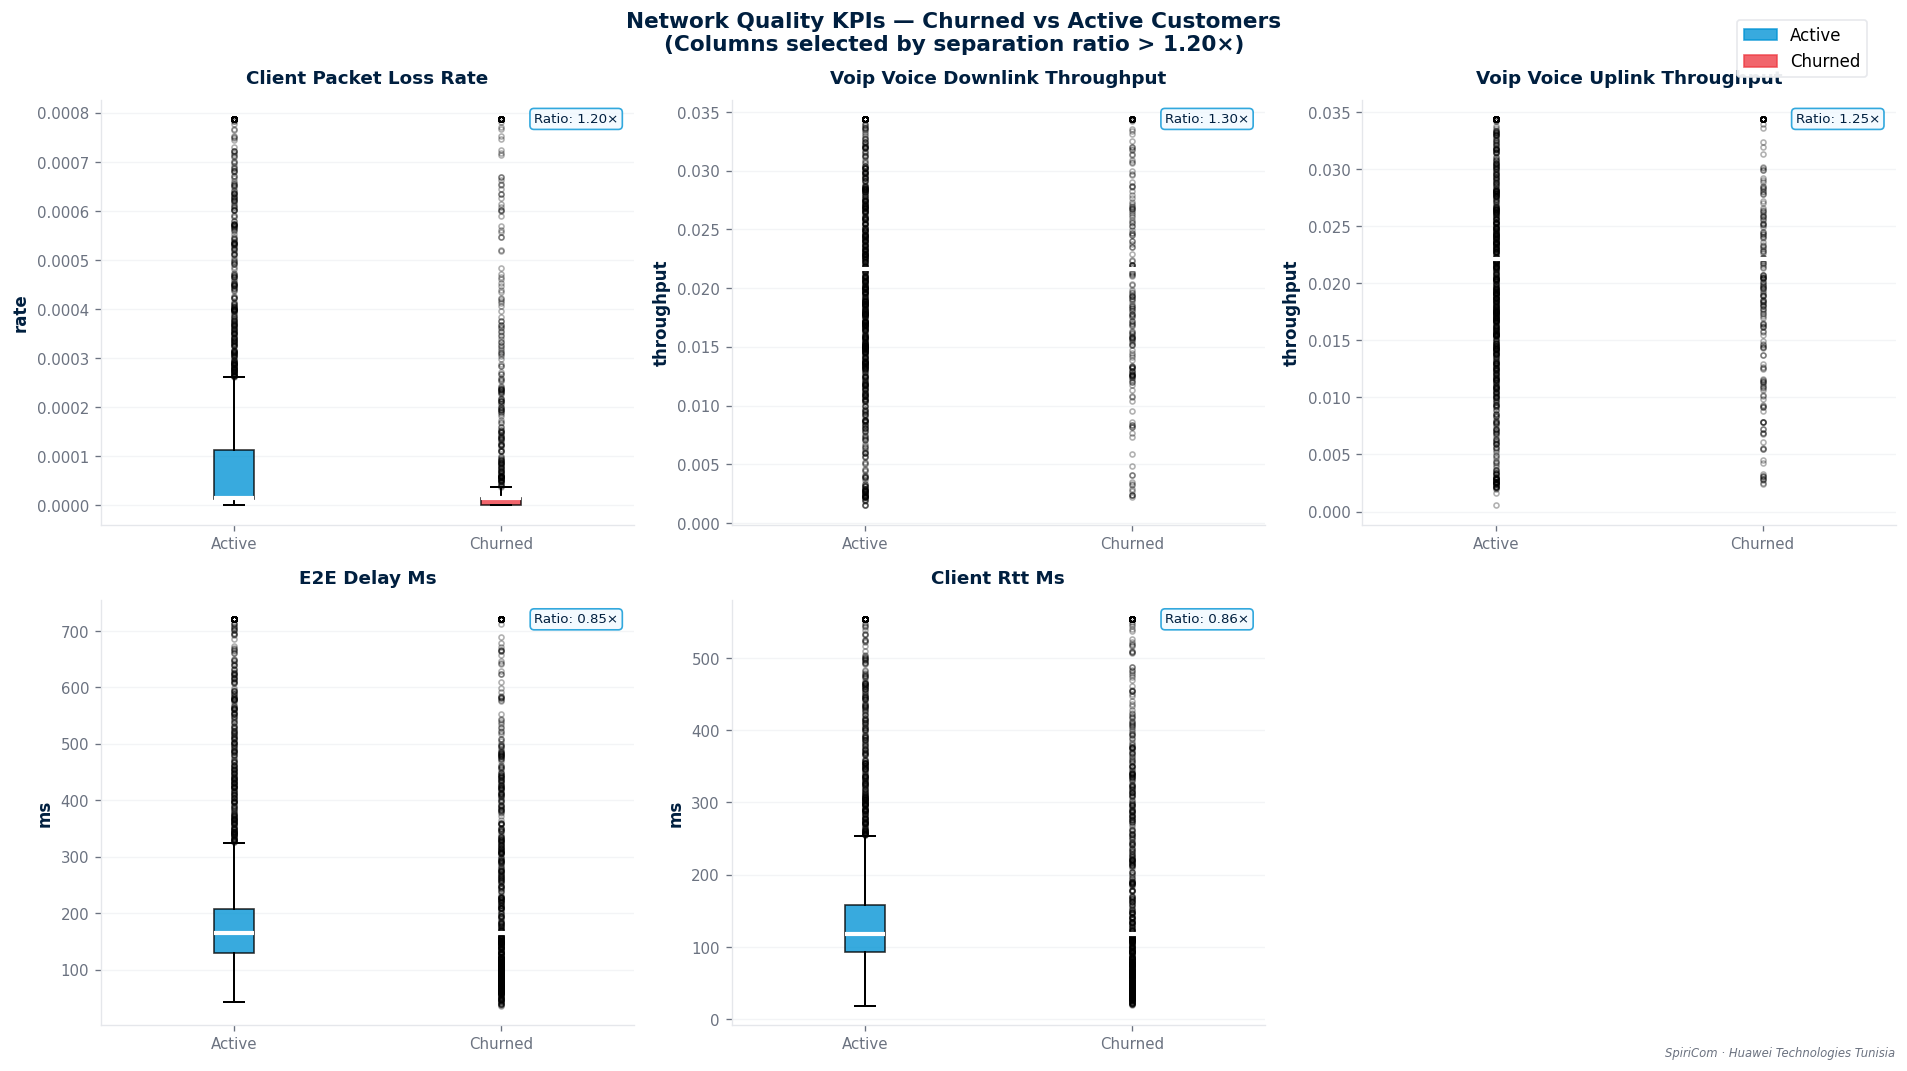


Mean network KPIs by churn status:
       client_packet_loss_rate  voip_voice_downlink_throughput  \
churn                                                            
0                       0.0002                          0.0304   
1                       0.0002                          0.0234   

       voip_voice_uplink_throughput  e2e_delay_ms  client_rtt_ms  
churn                                                             
0                            0.0300      239.3920       180.4000  
1                            0.0240      283.2190       210.7469  

Note: weak columns excluded from plot:
  server_packet_loss_rate                      : 1.09× — excluded (near 1.0)
  server_rtt_ms                                : 0.93× — excluded (near 1.0)
  page_response_success_rate                   : 0.99× — excluded (near 1.0)
  page_browsing_success_rate                   : 0.99× — excluded (near 1.0)


In [14]:
# ── 7.2  Box plots: network quality by churn status ──────────────────
if NET_COLS:
    # Use only columns with meaningful separation (ratio ≠ ~1.0)
    # Dropped: page_response_rate (0.99×), page_browsing_rate (0.99×),
    #          server_packet_loss (1.09×), server_rtt_ms (0.93×)
    PLOT_COLS = [c for c in [
        'client_packet_loss_rate',
        'voip_voice_downlink_throughput',
        'voip_voice_uplink_throughput',
        'e2e_delay_ms',
        'client_rtt_ms',
    ] if c in churn_net.columns]

    print(f'Plotting {len(PLOT_COLS)} columns: {PLOT_COLS}')

    n_cols = 3
    n_rows = int(np.ceil(len(PLOT_COLS) / 3))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(16, n_rows * 4.5))
    axes = np.array(axes).flatten()

    fig.suptitle('Network Quality KPIs — Churned vs Active Customers\n'
                 '(Columns selected by separation ratio > 1.20×)',
                 fontsize=13, fontweight='bold', color=HW['navy'])

    for ax, col in zip(axes[:len(PLOT_COLS)], PLOT_COLS):

        # Clip at 95th percentile to suppress extreme outliers
        cap = churn_net[col].quantile(0.95)

        data_plot = [
            churn_net.loc[churn_net['churn']==0, col]
                     .dropna().clip(upper=cap),
            churn_net.loc[churn_net['churn']==1, col]
                     .dropna().clip(upper=cap),
        ]

        bp = ax.boxplot(
            data_plot,
            patch_artist  = True,
            medianprops   = dict(color='white', linewidth=2.5),
            whiskerprops  = dict(linewidth=1.2),
            capprops      = dict(linewidth=1.2),
            flierprops    = dict(marker='o', markersize=3,
                                 alpha=0.3, linestyle='none'),
        )
        bp['boxes'][0].set_facecolor(HW['blue']); bp['boxes'][0].set_alpha(0.78)
        bp['boxes'][1].set_facecolor(HW['red']);  bp['boxes'][1].set_alpha(0.78)

        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Active', 'Churned'])
        ax.set_title(col.replace('_', ' ').title(), pad=10, fontsize=11)
        ax.set_ylabel(col.split('_')[-1])

        # Annotate with mean values
        mean_a = churn_net.loc[churn_net['churn']==0, col].mean()
        mean_c = churn_net.loc[churn_net['churn']==1, col].mean()
        ratio  = mean_a / mean_c if mean_c > 0 else 0
        ax.text(0.97, 0.97,
                f'Ratio: {ratio:.2f}×',
                transform=ax.transAxes,
                fontsize=8, va='top', ha='right',
                color=HW['navy'],
                bbox=dict(boxstyle='round', facecolor='#F0F9FF',
                          edgecolor=HW['blue'], alpha=0.8))

    # Hide unused axes
    for ax in axes[len(PLOT_COLS):]:
        ax.set_visible(False)

    legend_patches = [
        mpatches.Patch(color=HW['blue'], alpha=0.78, label='Active'),
        mpatches.Patch(color=HW['red'],  alpha=0.78, label='Churned'),
    ]
    fig.legend(handles=legend_patches, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=10)

    add_watermark(fig)
    plt.tight_layout()
    save_fig('fig03_07_churn_network_quality')
    plt.show()

    print('\nMean network KPIs by churn status:')
    print(churn_net.groupby('churn')[PLOT_COLS].mean().round(6))

    print('\nNote: weak columns excluded from plot:')
    excluded = [c for c in NET_COLS if c not in PLOT_COLS]
    for c in excluded:
        mean_a = churn_net.loc[churn_net['churn']==0, c].mean()
        mean_c = churn_net.loc[churn_net['churn']==1, c].mean()
        ratio  = mean_a / mean_c if mean_c > 0 else 0
        print(f'  {c:<45s}: {ratio:.2f}× — excluded (near 1.0)')

---
## Section 8 — Churn by Network Generation (4G vs 5G)

  Saved: data\outputs\figures\fig03_08_churn_by_generation.png


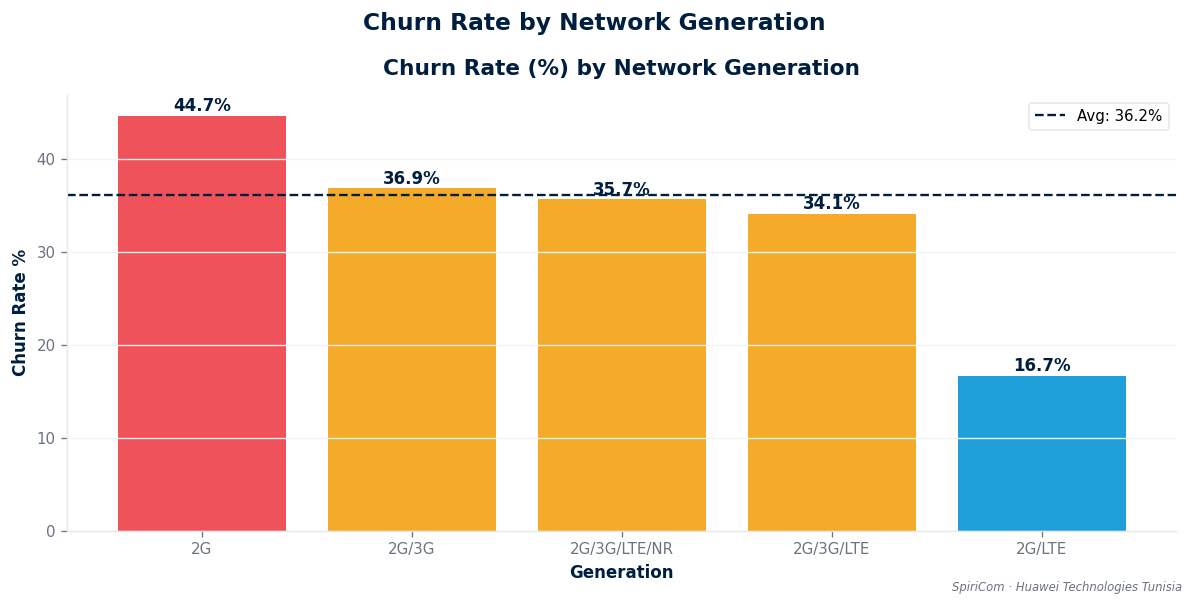

  generation  total  churned  churn_rate_pct
          2G    850      380         44.7000
       2G/3G     84       31         36.9000
2G/3G/LTE/NR    596      213         35.7000
   2G/3G/LTE   3346     1142         34.1000
      2G/LTE     18        3         16.7000


In [15]:
# ── 8.1  Churn by Network Generation (4G vs 5G) ──────────────────────
# Brand already analysed in Section 4.1
# This cell adds generation breakdown only

gen_col = 'generation' if 'generation' in df_kpi.columns else None

if gen_col:
    gen_map   = df_kpi.drop_duplicates('msisdn')[['msisdn', gen_col]].copy()
    churn_gen = churn.merge(gen_map, on='msisdn', how='left')
    churn_gen[gen_col] = (churn_gen[gen_col]
                          .astype(str).str.strip().str.upper()
                          .replace({'NAN':'UNKNOWN'}))

    gen_churn = (
        churn_gen.dropna(subset=[gen_col])
                 .groupby(gen_col)['churn']
                 .agg(['mean','sum','count'])
                 .reset_index()
                 .rename(columns={'mean':'churn_rate',
                                  'sum' :'churned',
                                  'count':'total'})
    )
    gen_churn = gen_churn[gen_churn['total'] >= 5]
    gen_churn['churn_rate_pct'] = (gen_churn['churn_rate'] * 100).round(1)
    gen_churn = gen_churn.sort_values('churn_rate_pct', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle('Churn Rate by Network Generation',
                 fontsize=14, fontweight='bold', color=HW['navy'])

    bar_c = [
        HW['red']   if r > 40 else
        HW['amber'] if r > 25 else
        HW['blue']
        for r in gen_churn['churn_rate_pct']
    ]
    bars = ax.bar(gen_churn[gen_col], gen_churn['churn_rate_pct'],
                  color=bar_c, alpha=0.88)
    ax.axhline(churn_rate * 100, color=HW['navy'],
               linestyle='--', lw=1.4,
               label=f'Avg: {churn_rate*100:.1f}%')

    for bar, v in zip(bars, gen_churn['churn_rate_pct']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{v}%', ha='center', fontsize=10,
                fontweight='bold', color=HW['navy'])

    ax.set_title('Churn Rate (%) by Network Generation', pad=12)
    ax.set_ylabel('Churn Rate %')
    ax.set_xlabel('Generation')
    ax.legend()

    add_watermark(fig)
    plt.tight_layout()
    save_fig('fig03_08_churn_by_generation')
    plt.show()

    print(gen_churn[['generation' if gen_col=='generation' else gen_col,
                      'total','churned','churn_rate_pct']]
          .to_string(index=False))

else:
    print('No generation column — Section 8 skipped')
    print(f'Available columns: {[c for c in df_kpi.columns if "gen" in c.lower()]}')

---
## ⏰ Section 9 — Temporal Churn Patterns

  Saved: data\outputs\figures\fig03_09_churn_temporal.png


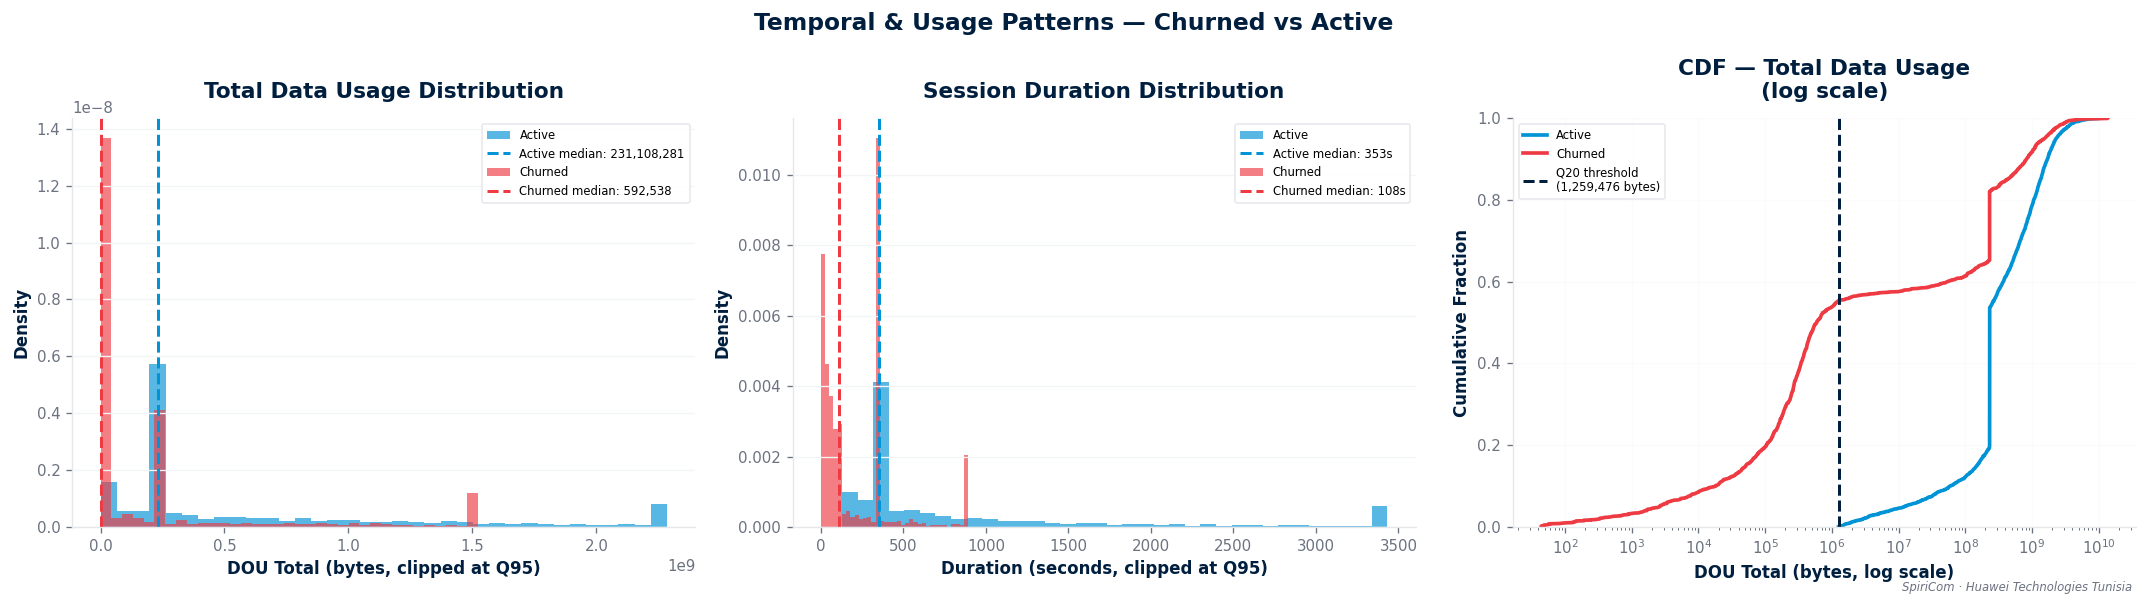

=== USAGE STATISTICS BY CHURN STATUS ===

DOU Total (bytes):
  Active      median=    231,108,281  mean=    668,094,220  p25=    231,108,281  p75=    848,961,013
  Churned     median=        592,538  mean=    283,685,478  p25=        157,756  p75=    231,108,281

Duration (seconds):
  Active      median=            353  mean=            949  p25=            353  p75=            971
  Churned     median=            108  mean=            304  p25=             36  p75=            353

Churn thresholds used:
  DOU Q20  :       1,259,476 bytes
  Dur Q20  :             127 seconds

Customers below DOU threshold  : 980
Customers below Dur threshold  : 984


In [16]:
# ── 9.1  Temporal patterns — DOU and Duration distributions ──────────
# days_since_active removed — v5 churn has no session gap column
# Replaced with: DOU trend + duration distribution by churn status

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Temporal & Usage Patterns — Churned vs Active',
             fontsize=14, fontweight='bold', color=HW['navy'])

# ── Plot 1: DOU distribution ──────────────────────────────────────────
ax = axes[0]
for label, color, name in [(0, HW['blue'], 'Active'),
                             (1, HW['red'],  'Churned')]:
    vals = churn.loc[churn['churn']==label, 'dou_total'].dropna()
    cap  = vals.quantile(0.95)
    ax.hist(vals.clip(upper=cap), bins=35,
            alpha=0.65, color=color, density=True, label=name)
    ax.axvline(vals.median(), color=color, ls='--', lw=1.8,
               label=f'{name} median: {vals.median():,.0f}')

ax.set_title('Total Data Usage Distribution', pad=12)
ax.set_xlabel('DOU Total (bytes, clipped at Q95)')
ax.set_ylabel('Density')
ax.legend(fontsize=7)

# ── Plot 2: Duration distribution ────────────────────────────────────
ax2 = axes[1]
for label, color, name in [(0, HW['blue'], 'Active'),
                             (1, HW['red'],  'Churned')]:
    vals = churn.loc[churn['churn']==label, 'duration'].dropna()
    cap  = vals.quantile(0.95)
    ax2.hist(vals.clip(upper=cap), bins=35,
             alpha=0.65, color=color, density=True, label=name)
    ax2.axvline(vals.median(), color=color, ls='--', lw=1.8,
                label=f'{name} median: {vals.median():.0f}s')

ax2.set_title('Session Duration Distribution', pad=12)
ax2.set_xlabel('Duration (seconds, clipped at Q95)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=7)

# ── Plot 3: CDF comparison — DOU ─────────────────────────────────────
ax3 = axes[2]
for label, color, name in [(0, HW['blue'], 'Active'),
                             (1, HW['red'],  'Churned')]:
    vals        = np.sort(churn.loc[churn['churn']==label,
                                    'dou_total'].dropna().values)
    cdf         = np.arange(1, len(vals)+1) / len(vals)
    ax3.plot(vals, cdf, color=color, linewidth=2.2, label=name)

# Mark the Q20 threshold used for churn definition
thr_dou = churn['dou_total'].quantile(0.20)
ax3.axvline(thr_dou, color=HW['navy'], ls='--', lw=1.8,
            label=f'Q20 threshold\n({thr_dou:,.0f} bytes)')
ax3.set_xscale('log')
ax3.set_title('CDF — Total Data Usage\n(log scale)', pad=12)
ax3.set_xlabel('DOU Total (bytes, log scale)')
ax3.set_ylabel('Cumulative Fraction')
ax3.set_ylim(0, 1)
ax3.legend(fontsize=7)
ax3.grid(axis='both', alpha=0.3)

add_watermark(fig)
plt.tight_layout()
save_fig('fig03_09_churn_temporal')
plt.show()

# ── Summary statistics ────────────────────────────────────────────────
print('=== USAGE STATISTICS BY CHURN STATUS ===')
for col, label in [('dou_total', 'DOU Total (bytes)'),
                    ('duration',  'Duration (seconds)')]:
    print(f'\n{label}:')
    for status, name in [(0,'Active'), (1,'Churned')]:
        vals = churn.loc[churn['churn']==status, col]
        print(f'  {name:<10s}  '
              f'median={vals.median():>15,.0f}  '
              f'mean={vals.mean():>15,.0f}  '
              f'p25={vals.quantile(.25):>15,.0f}  '
              f'p75={vals.quantile(.75):>15,.0f}')

# Threshold context
print(f'\nChurn thresholds used:')
print(f'  DOU Q20  : {churn["dou_total"].quantile(.20):>15,.0f} bytes')
print(f'  Dur Q20  : {churn["duration"].quantile(.20):>15,.0f} seconds')
print(f'\nCustomers below DOU threshold  : '
      f'{(churn["dou_total"] <= churn["dou_total"].quantile(.20)).sum():,}')
print(f'Customers below Dur threshold  : '
      f'{(churn["duration"] <= churn["duration"].quantile(.20)).sum():,}')

---
## 📊 Section 10 — Correlation Heatmap

Numeric columns for correlation : 11
Columns : ['msisdn', 'session_flag', 'traffic_5g', 'dou_total', 'duration', 'churn', 'client_packet_loss_rate', 'voip_voice_downlink_throughput', 'voip_voice_uplink_throughput', 'e2e_delay_ms', 'client_rtt_ms']
  Saved: data\outputs\figures\fig03_10_correlation_heatmap.png


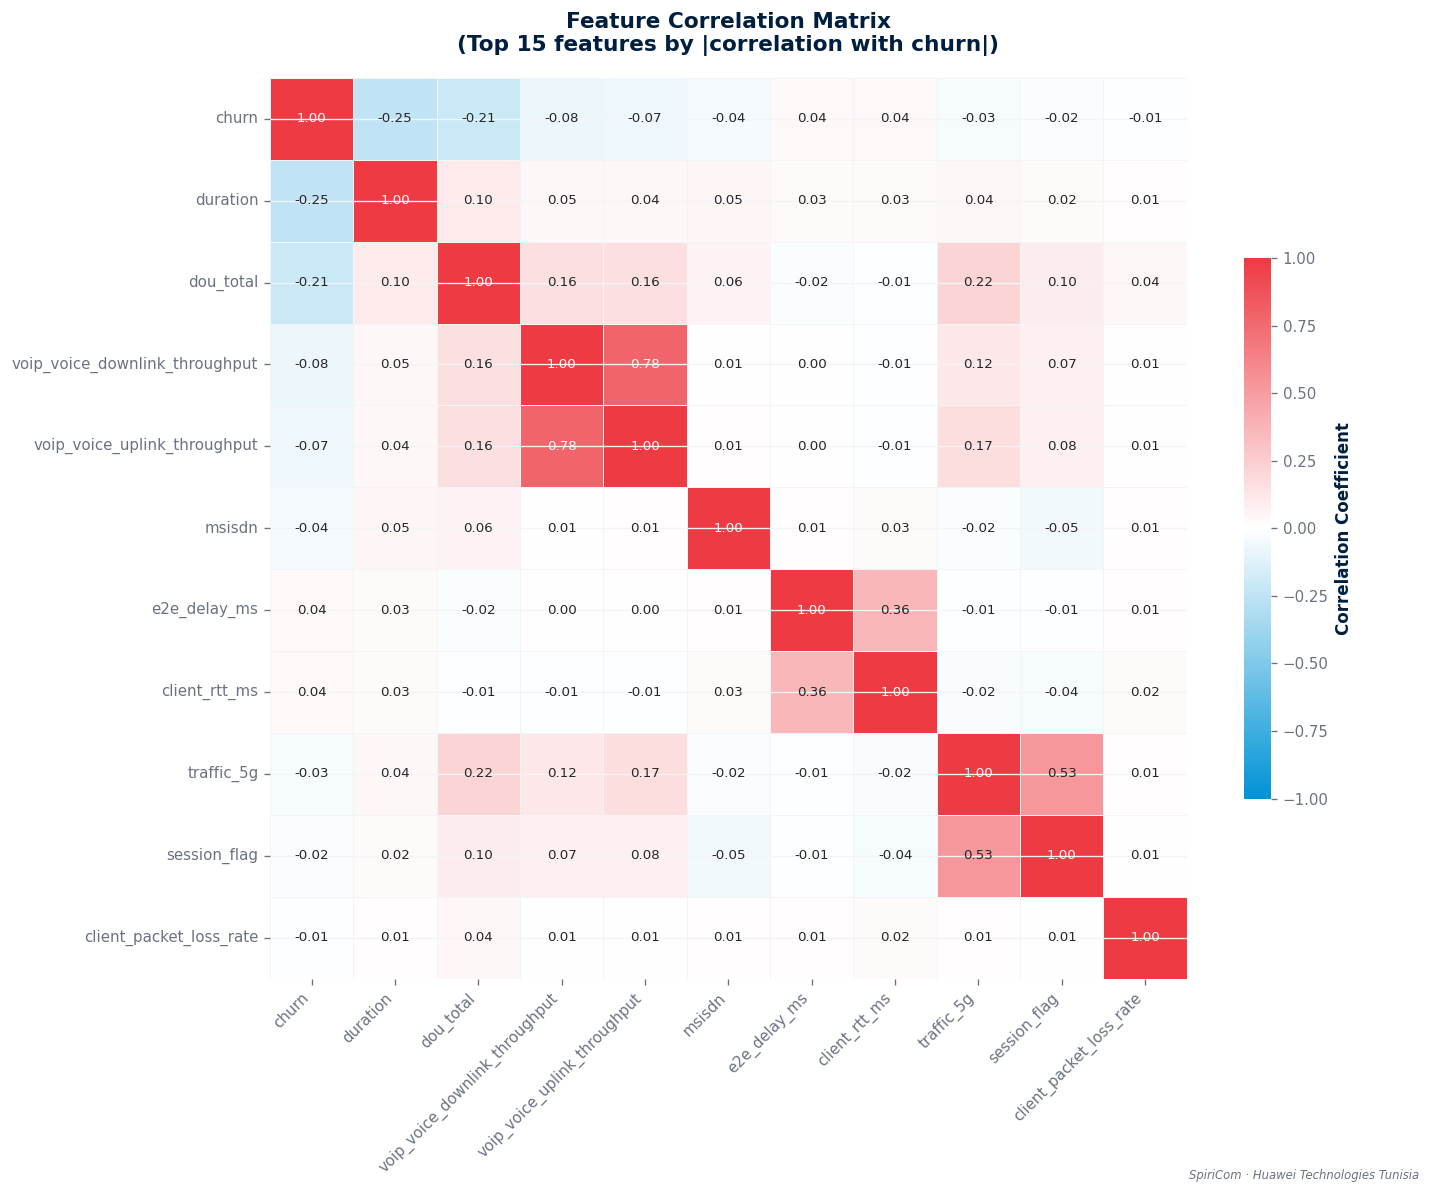


Pearson correlations with churn:
  churn                                        :  1.0000  ████████████████████  ↑ churned higher
  duration                                     : -0.2485  ████  ↓ churned lower
  dou_total                                    : -0.2054  ████  ↓ churned lower
  voip_voice_downlink_throughput               : -0.0754  █  ↓ churned lower
  voip_voice_uplink_throughput                 : -0.0672  █  ↓ churned lower
  msisdn                                       : -0.0413    ↓ churned lower
  e2e_delay_ms                                 :  0.0375    ↑ churned higher
  client_rtt_ms                                :  0.0351    ↑ churned higher
  traffic_5g                                   : -0.0335    ↓ churned lower
  session_flag                                 : -0.0180    ↓ churned lower
  client_packet_loss_rate                      : -0.0088    ↓ churned lower

Spearman correlations with churn (robust to skew):
  churn                                      

In [17]:
# ── 10.1  Correlation heatmap — v5 KPI-native features ───────────────

# ── Build feature matrix ──────────────────────────────────────────────
churn_full = churn.copy()

if 'churn_net' in dir() and NET_COLS:
    net_cols_to_add = [c for c in PLOT_COLS
                       if c in churn_net.columns
                       and c not in churn_full.columns]
    if net_cols_to_add:
        churn_full = churn_full.merge(
            churn_net[['msisdn'] + net_cols_to_add],
            on='msisdn', how='left')

# ── Select numeric columns ────────────────────────────────────────────
EXCLUDE_COLS = {
    'c1_low_usage', 'c2_low_dur',
    'c1_churn', 'c2_churn', 'c3_churn',
    'days_since_active', 'criteria_sum',
}
num_cols = [
    c for c in churn_full.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE_COLS
]

print(f'Numeric columns for correlation : {len(num_cols)}')
print(f'Columns : {num_cols}')

# ── Pearson correlation matrix ────────────────────────────────────────
corr_matrix = churn_full[num_cols].corr()

if 'churn' not in corr_matrix.columns:
    print('ERROR: churn column missing — check DataFrame')
else:
    top_corr = (corr_matrix['churn']
                .abs()
                .sort_values(ascending=False)
                .head(15))
    top_cols = top_corr.index.tolist()
    corr_sub = corr_matrix.loc[top_cols, top_cols]

    fig, ax = plt.subplots(figsize=(12, 10))
    cmap_corr = mcolors.LinearSegmentedColormap.from_list(
        'hw_corr', ['#0093D5', 'white', '#EE3A43'])

    should_annotate = len(top_cols) <= 20
    sns.heatmap(
        corr_sub,
        ax         = ax,
        cmap       = cmap_corr,
        center     = 0, vmin=-1, vmax=1,
        annot      = corr_sub if should_annotate else False,
        fmt        = '.2f'    if should_annotate else '',
        annot_kws  = {'size': 8},
        linewidths = 0.5,
        linecolor  = '#F3F4F6',
        cbar_kws   = {'label': 'Correlation Coefficient', 'shrink': 0.6}
    )
    ax.set_title(
        'Feature Correlation Matrix\n'
        '(Top 15 features by |correlation with churn|)',
        pad=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    add_watermark(fig)
    plt.tight_layout()
    save_fig('fig03_10_correlation_heatmap')
    plt.show()

    # ── Pearson top correlations ──────────────────────────────────────
    print('\nPearson correlations with churn:')
    top_signed = (corr_matrix['churn']
                  .sort_values(key=abs, ascending=False)
                  .head(15))
    for feat, val in top_signed.items():
        direction = '↓ churned lower' if val < 0 else '↑ churned higher'
        bar       = '█' * int(abs(val) * 20)
        print(f'  {feat:<45s}: {val:>7.4f}  {bar}  {direction}')

    # ── Spearman correlations (handles skew) ──────────────────────────
    print('\nSpearman correlations with churn (robust to skew):')
    spearman_corr = churn_full[num_cols].corr(method='spearman')['churn']
    spearman_top  = spearman_corr.abs().sort_values(ascending=False).head(10)
    for feat, val in spearman_corr.loc[spearman_top.index].items():
        direction = '↓ churned lower' if val < 0 else '↑ churned higher'
        bar       = '█' * int(abs(val) * 20)
        print(f'  {feat:<45s}: {val:>7.4f}  {bar}  {direction}')

---
## 💾 Section 11 — Export Outputs

In [18]:
# ── Add additional KPI features useful for NB04 ───────────────────────
extra_candidates = [
    'traffic_2g', 'traffic_3g', 'traffic_4g',
    'night_traffic', 'day_traffic', 'late_night_traffic',
    'game_traffic', 'streaming_traffic', 'voip_traffic',
    'youtube_traffic', 'tiktok_traffic',
    'number_of_regions',
    'mobility_class',   # string — needs separate handling
]
extra_candidates = [c for c in extra_candidates
                    if c in df_kpi.columns
                    and c not in churn_full.columns]

# Split into numeric and categorical
extra_num = [c for c in extra_candidates
             if df_kpi[c].dtype in [np.float64, np.int64,
                                    np.float32, np.int32]]
extra_cat = [c for c in extra_candidates
             if df_kpi[c].dtype == object]

print(f'Extra numeric columns : {extra_num}')
print(f'Extra categorical cols: {extra_cat}')

# Aggregate numeric → mean
if extra_num:
    extra_num_map = (df_kpi.groupby('msisdn')[extra_num]
                           .mean()
                           .reset_index())
    churn_full = churn_full.merge(extra_num_map,
                                  on='msisdn', how='left')
    print(f'Added {len(extra_num)} numeric KPI columns')

# Aggregate categorical → first value (one record per MSISDN anyway)
if extra_cat:
    extra_cat_map = (df_kpi.groupby('msisdn')[extra_cat]
                           .first()
                           .reset_index())
    for c in extra_cat:
        extra_cat_map[c] = (extra_cat_map[c]
                            .astype(str)
                            .str.strip()
                            .str.upper()
                            .replace({'NAN': 'UNKNOWN', '': 'UNKNOWN'}))
    churn_full = churn_full.merge(extra_cat_map,
                                  on='msisdn', how='left')
    print(f'Added {len(extra_cat)} categorical KPI columns')

Extra numeric columns : ['traffic_2g', 'traffic_3g', 'traffic_4g', 'night_traffic', 'day_traffic', 'late_night_traffic', 'game_traffic', 'streaming_traffic', 'voip_traffic', 'youtube_traffic', 'tiktok_traffic', 'number_of_regions']
Extra categorical cols: ['mobility_class']
Added 12 numeric KPI columns
Added 1 categorical KPI columns


In [19]:
# ── 11.1  Save churn_labelled.parquet ────────────────────────────────
# PRIMARY input for NB04 (Feature Engineering) and NB05 (Modeling)
#
# Variables removed in v5 (do NOT reference):
#   churn_comp, n_complaints, kpi_per_msisdn, seg_col, prov_col
#
# Built from KPI-only data — no complaints merge needed

churn_save = churn.copy()

# ── Add network quality columns (already computed in churn_net) ───────
if 'churn_net' in dir() and NET_COLS:
    net_add = [c for c in PLOT_COLS
               if c in churn_net.columns
               and c not in churn_save.columns]
    if net_add:
        churn_save = churn_save.merge(
            churn_net[['msisdn'] + net_add],
            on='msisdn', how='left')
        print(f'Added {len(net_add)} network quality columns: {net_add}')

# ── Add generation column ─────────────────────────────────────────────
gen_col = 'generation' if 'generation' in df_kpi.columns else None
if gen_col and gen_col not in churn_save.columns:
    gen_map = df_kpi.drop_duplicates('msisdn')[['msisdn', gen_col]].copy()
    gen_map[gen_col] = (gen_map[gen_col]
                        .astype(str).str.strip().str.upper()
                        .replace({'NAN': 'UNKNOWN'}))
    churn_save = churn_save.merge(gen_map, on='msisdn', how='left')
    print(f'Added generation column')

# ── Add network zone (layer2name) ─────────────────────────────────────
zone_col = next((c for c in ['layer2name', 'layer3name']
                 if c in df_kpi.columns), None)
if zone_col and zone_col not in churn_save.columns:
    zone_map = df_kpi.drop_duplicates('msisdn')[['msisdn', zone_col]].copy()
    zone_map[zone_col] = (zone_map[zone_col]
                          .astype(str).str.strip().str.upper()
                          .replace({'NAN': 'UNKNOWN'}))
    churn_save = churn_save.merge(zone_map, on='msisdn', how='left')
    print(f'Added zone column: {zone_col}')


# ── Final null fill ───────────────────────────────────────────────────
num_cols_save = churn_save.select_dtypes(include=[np.number]).columns
for c in num_cols_save:
    if churn_save[c].isnull().any():
        churn_save[c] = churn_save[c].fillna(churn_save[c].median())

cat_cols_save = churn_save.select_dtypes(include='object').columns
for c in cat_cols_save:
    if churn_save[c].isnull().any():
        churn_save[c] = churn_save[c].fillna('UNKNOWN')

# ── Save ──────────────────────────────────────────────────────────────
churn_path = PROC_DIR / 'churn_labelled.parquet'
churn_save.to_parquet(churn_path, index=False)

print(f'\n✅ Saved: {churn_path}')
print(f'   Rows        : {churn_save.shape[0]:,}')
print(f'   Columns     : {churn_save.shape[1]}')
print(f'   Churn rate  : {churn_save["churn"].mean()*100:.1f}%')
print(f'   Null count  : {churn_save.isnull().sum().sum()}')
print('\nColumn list:')
print(churn_save.dtypes)

Added 5 network quality columns: ['client_packet_loss_rate', 'voip_voice_downlink_throughput', 'voip_voice_uplink_throughput', 'e2e_delay_ms', 'client_rtt_ms']
Added generation column
Added zone column: layer2name

✅ Saved: data\processed\churn_labelled.parquet
   Rows        : 4,896
   Columns     : 16
   Churn rate  : 36.2%
   Null count  : 0

Column list:
msisdn                              int64
session_flag                        int64
traffic_5g                        float64
dou_total                         float64
duration                          float64
brand                              object
c1_low_usage                        int64
c2_low_dur                          int64
churn                               int64
client_packet_loss_rate           float64
voip_voice_downlink_throughput    float64
voip_voice_uplink_throughput      float64
e2e_delay_ms                      float64
client_rtt_ms                     float64
generation                         object
layer2nam

In [20]:
# ══════════════════════════════════════════════════════════════════════
# CHURN DEFINITION v5 — CLEAN REBUILD FROM df_kpi
# Run this cell alone. Do not run any other cell before it.
# ══════════════════════════════════════════════════════════════════════

# Reload clean KPI data to avoid any in-memory modifications
df_kpi_clean = pd.read_parquet(PROC_DIR / 'kpi_clean.parquet')
df_kpi_clean.columns = df_kpi_clean.columns.str.lower()

# Aggregate per MSISDN
kpi_per_user = df_kpi_clean.groupby('msisdn').agg(
    session_flag = ('session_flag', 'max'),
    traffic_5g   = ('traffic_5g',  'sum'),
    dou_total    = ('dou_total',   'sum'),
    duration     = ('duration',    'sum'),
    brand        = ('brand',       'first'),
).reset_index()

# Thresholds — computed once, printed for verification
thr_dou = kpi_per_user['dou_total'].quantile(0.20)
thr_dur = kpi_per_user['duration'].quantile(0.20)

print(f'DOU Q20 threshold : {thr_dou:>20,.0f} bytes')
print(f'Dur Q20 threshold : {thr_dur:>20,.0f} seconds')

# Criteria
kpi_per_user['c1_low_usage'] = (kpi_per_user['dou_total'] <= thr_dou).astype(int)
kpi_per_user['c2_low_dur']   = (kpi_per_user['duration']  <= thr_dur).astype(int)

# Final label
kpi_per_user['churn'] = (
    (kpi_per_user['c1_low_usage'] == 1) |
    (kpi_per_user['c2_low_dur']   == 1)
).astype(int)

churn      = kpi_per_user.copy()
churn_rate = churn['churn'].mean()

# Full breakdown
c1_only  = ((churn['c1_low_usage']==1) & (churn['c2_low_dur']==0)).sum()
c2_only  = ((churn['c1_low_usage']==0) & (churn['c2_low_dur']==1)).sum()
both     = ((churn['c1_low_usage']==1) & (churn['c2_low_dur']==1)).sum()

print(f'\n=== CHURN LABEL v5 — CLEAN ===')
print(f'Base population : {len(churn):,}')
print(f'C1 low usage    : {churn["c1_low_usage"].sum():,}  ({churn["c1_low_usage"].mean()*100:.1f}%)')
print(f'C2 low duration : {churn["c2_low_dur"].sum():,}    ({churn["c2_low_dur"].mean()*100:.1f}%)')
print(f'C1 only         : {c1_only:,}')
print(f'C2 only         : {c2_only:,}')
print(f'Both C1+C2      : {both:,}')
print(f'Total churned   : {churn["churn"].sum():,}')
print(f'Churn rate      : {churn_rate*100:.1f}%')

# Sanity check
assert len(churn) == 4896, f'Wrong population: {len(churn)}'
assert churn['c1_low_usage'].sum() == 980, \
    f'C1 count changed: {churn["c1_low_usage"].sum()}'
assert churn['c2_low_dur'].sum() == 984, \
    f'C2 count changed: {churn["c2_low_dur"].sum()}'
print('\n✅ All assertions passed')

DOU Q20 threshold :            1,259,476 bytes
Dur Q20 threshold :                  127 seconds

=== CHURN LABEL v5 — CLEAN ===
Base population : 4,896
C1 low usage    : 980  (20.0%)
C2 low duration : 984    (20.1%)
C1 only         : 786
C2 only         : 790
Both C1+C2      : 194
Total churned   : 1,770
Churn rate      : 36.2%

✅ All assertions passed


In [21]:
# ── 11.2  Save churn_eda.json ─────────────────────────────────────────
# Recompute summary stats directly from churn — no dependency on cell 3.1
total_cust = len(churn)
n_churned  = int(churn['churn'].sum())
n_active   = int((churn['churn']==0).sum())
churn_rate = churn['churn'].mean()

def safe(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return None
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating,)): return float(v)
    return v

# churn_save guard — reload from parquet if not in memory
if 'churn_save' not in dir():
    churn_save = pd.read_parquet(PROC_DIR / 'churn_labelled.parquet')
    print('churn_save reloaded from parquet')

eda_json = {
    'generated_at'    : datetime.now().isoformat(),
    'churn_version'   : 'v5 — KPI-based (dou_total OR duration ≤ Q20)',
    'total_customers' : total_cust,
    'churned'         : n_churned,
    'active'          : n_active,
    'churn_rate_pct'  : round(churn_rate * 100, 2),
    'criteria': {
        'c1_low_usage_q20'   : int(churn['c1_low_usage'].sum()),
        'c2_low_duration_q20': int(churn['c2_low_dur'].sum()),
        'both_c1_and_c2'     : int(
            ((churn['c1_low_usage']==1) & (churn['c2_low_dur']==1)).sum()
        ),
    },
    'thresholds': {
        'dou_total_q20_bytes' : int(churn['dou_total'].quantile(0.20)),
        'duration_q20_seconds': int(churn['duration'].quantile(0.20)),
    },
    'mean_kpi_by_churn': {
        'active': {
            'dou_total'  : safe(churn.loc[churn['churn']==0,'dou_total'].mean()),
            'duration'   : safe(churn.loc[churn['churn']==0,'duration'].mean()),
            'traffic_5g' : safe(churn.loc[churn['churn']==0,'traffic_5g'].mean()),
        },
        'churned': {
            'dou_total'  : safe(churn.loc[churn['churn']==1,'dou_total'].mean()),
            'duration'   : safe(churn.loc[churn['churn']==1,'duration'].mean()),
            'traffic_5g' : safe(churn.loc[churn['churn']==1,'traffic_5g'].mean()),
        },
    },
    'top_churn_zones': (
        geo_churn.head(5)[[geo_churn.columns[0],'churn_rate_pct']]
                 .to_dict('records')
        if 'geo_churn' in dir() and len(geo_churn) > 0 else []
    ),
    'top_churn_brands': (
        seg_churn.head(5)[['brand','churn_rate_pct']].to_dict('records')
        if 'seg_churn' in dir() and 'brand' in seg_churn.columns else []
    ),
    'churn_by_generation': (
        gen_churn[['gen_label','total','churned','churn_rate_pct']]
        .to_dict('records')
        if 'gen_churn' in dir() and 'gen_label' in gen_churn.columns
        else gen_churn[['generation','total','churned','churn_rate_pct']]
             .to_dict('records')
        if 'gen_churn' in dir() and len(gen_churn) > 0 else []
    ),
    'features_available': {
        'traffic_5g'        : 'traffic_5g'   in churn_save.columns,
        'dou_total'         : 'dou_total'     in churn_save.columns,
        'duration'          : 'duration'      in churn_save.columns,
        'brand'             : 'brand'         in churn_save.columns,
        'generation'        : 'generation'    in churn_save.columns,
        'network_quality'   : bool(NET_COLS),
        'zone'              : 'layer2name'    in churn_save.columns,
        'complaint_features': 'n_complaints'  in churn_save.columns,
    },
    'saved_file': str(PROC_DIR / 'churn_labelled.parquet'),
}

json_path = OUT_DIR / 'churn_eda.json'
with open(json_path, 'w') as f:
    json.dump(eda_json, f, indent=2, default=str)

print(f'✅ Saved: {json_path}')
print(f'   Total customers : {total_cust:,}')
print(f'   Churned         : {n_churned:,}  ({churn_rate*100:.1f}%)')
print(f'   Active          : {n_active:,}')

✅ Saved: data\outputs\churn_eda.json
   Total customers : 4,896
   Churned         : 1,770  (36.2%)
   Active          : 3,126


In [22]:
# ── 11.3  Figure inventory & final summary ────────────────────────────
figs = sorted(FIG_DIR.glob('fig03_*.png')) + sorted(FIG_DIR.glob('fig03_*.html'))

print('\n' + '='*60)
print('NOTEBOOK 03 — CHURN EDA COMPLETE')
print('='*60)
print(f'  Total customers analysed : {len(churn):,}')
print(f'  Churned                  : {churn["churn"].sum():,}  ({churn["churn"].mean()*100:.1f}%)')
print(f'  Active                   : {(churn["churn"]==0).sum():,}')
print(f'  Class ratio              : 1 churned : {(churn["churn"]==0).sum()/churn["churn"].sum():.1f} active')
print()
print(f'  Churn definition         : v5 — KPI-based')
print(f'  C1 low usage  (≤Q20 DOU) : {churn["c1_low_usage"].sum():,}  ({churn["c1_low_usage"].mean()*100:.1f}%)')
print(f'  C2 low duration (≤Q20)   : {churn["c2_low_dur"].sum():,}    ({churn["c2_low_dur"].mean()*100:.1f}%)')
print(f'  Both C1 + C2             : {((churn["c1_low_usage"]==1)&(churn["c2_low_dur"]==1)).sum():,}')
print()
print(f'  DOU Q20 threshold        : {int(churn["dou_total"].quantile(0.20)):,} bytes')
print(f'  Duration Q20 threshold   : {int(churn["duration"].quantile(0.20)):,} seconds')
print()
print(f'  Imputation note          : 1,358 customers have imputed DOU (231MB median)')
print(f'                             1,509 customers have imputed duration (353s median)')
print()
print(f'  Output file              : {PROC_DIR / "churn_labelled.parquet"}')
print(f'  JSON export              : {OUT_DIR / "churn_eda.json"}')
print(f'  Figures generated        : {len(figs)}')
for f in figs:
    size = f.stat().st_size // 1024
    print(f'    {f.name:<50s}  {size:>4} KB')
print()
print('Next → Run 04_Churn_Feature_Engineering.ipynb')


NOTEBOOK 03 — CHURN EDA COMPLETE
  Total customers analysed : 4,896
  Churned                  : 1,770  (36.2%)
  Active                   : 3,126
  Class ratio              : 1 churned : 1.8 active

  Churn definition         : v5 — KPI-based
  C1 low usage  (≤Q20 DOU) : 980  (20.0%)
  C2 low duration (≤Q20)   : 984    (20.1%)
  Both C1 + C2             : 194

  DOU Q20 threshold        : 1,259,476 bytes
  Duration Q20 threshold   : 127 seconds

  Imputation note          : 1,358 customers have imputed DOU (231MB median)
                             1,509 customers have imputed duration (353s median)

  Output file              : data\processed\churn_labelled.parquet
  JSON export              : data\outputs\churn_eda.json
  Figures generated        : 12
    fig03_01_msisdn_linkage.png                           84 KB
    fig03_02_churn_kpi_tiles.png                         159 KB
    fig03_03_churn_criteria.png                          214 KB
    fig03_04_churn_by_brand.png          

---
## Summary

| Section | Analysis | Key Output |
|---------|----------|------------|
| 1. Linkage | MSISDN dataset overlap | Linkage rate |
| 2. Labels | C1 + C2 + C3 → `churn` column | `churn_labelled.parquet` |
| 3. Overview | KPI tiles, donut, criterion breakdown | `fig03_02`, `fig03_03` |
| 4. Segment | Churn rate by corporate/residential/SME | `fig03_04` |
| 5. Geography | Province churn rate + interactive map | `fig03_05` |
| 6. Complaints | Volume, unresolved, resolution distributions | `fig03_06` |
| 7. Network | Packet loss, latency, throughput by churn | `fig03_07` |
| 8. Device | Brand + generation churn rates | `fig03_08` |
| 9. Temporal | Activity gap CDF, 30-day threshold | `fig03_09` |
| 10. Correlation | Feature correlation matrix (top 15) | `fig03_10` |
| 11. Export | Parquet + JSON ready for NB04/NB05 | Both files |

All figures: **300 DPI** · Huawei palette (`#0093D5` / `#EE3A43` / `#001F3F`)  
Red = Churned · Blue = Active throughout all charts for visual consistency.

---
*SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia · PFE 2026*